# Notebook 2 Time Series Jena Climate - Transformer Model

### Developed by:

- António Cruz (140129)
- Cátia Brás (120093)
- Ricardo Kyaseller (95813)

# Até ao Capítulo 5 não há comentários pois é igual ao notebook 1.

# 1. Libraries

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"   # This must be set BEFORE importing TF

import warnings
warnings.filterwarnings("ignore", message="IProgress not found")

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import keras
from keras import activations as activations
from keras import applications as applications
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import random
import time
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

gpus = tf.config.list_physical_devices("GPU")
print("GPUs:", gpus)

for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)


I0000 00:00:1773073379.018625    9811 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773073381.046711    9811 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# 2. Get Data

## Climate Data Time-Series

Dataset used for this mini-project is Jena Climate dataset recorded by the
[Max Planck Institute for Biogeochemistry](https://www.bgc-jena.mpg.de/wetter/).
The dataset consists of 14 features recorded once per 10 minutes.

**Location**: Weather Station, Max Planck Institute for Biogeochemistry
in Jena, Germany

**Time-frame Considered**: Jan 10, 2009 - December 31, 2016


The table below shows the column names, their value formats, and their description.

Index| Features      |Format             |Description
-----|---------------|-------------------|-----------------------
1    |Date Time      |01.01.2009 00:10:00|Date-time reference
2    |p (mbar)       |996.52             |The pascal SI derived unit of pressure used to quantify internal pressure. Meteorological reports typically state atmospheric pressure in millibars.
3    |T (degC)       |-8.02              |Temperature in Celsius
4    |Tpot (K)       |265.4              |Temperature in Kelvin
5    |Tdew (degC)    |-8.9               |Temperature in Celsius relative to humidity. Dew Point is a measure of the absolute amount of water in the air, the DP is the temperature at which the air cannot hold all the moisture in it and water condenses.
6    |rh (%)         |93.3               |Relative Humidity is a measure of how saturated the air is with water vapor, the %RH determines the amount of water contained within collection objects.
7    |VPmax (mbar)   |3.33               |Saturation vapor pressure
8    |VPact (mbar)   |3.11               |Vapor pressure
9    |VPdef (mbar)   |0.22               |Vapor pressure deficit
10   |sh (g/kg)      |1.94               |Specific humidity
11   |H2OC (mmol/mol)|3.12               |Water vapor concentration
12   |rho (g/m ** 3) |1307.75            |Airtight
13   |wv (m/s)       |1.03               |Wind speed
14   |max. wv (m/s)  |1.75               |Maximum wind speed
15   |wd (deg)       |152.3              |Wind direction in degrees

In [2]:
"""
from zipfile import ZipFile

uri = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"
zip_path = keras.utils.get_file(origin=uri, fname="jena_climate_2009_2016.csv.zip")
zip_file = ZipFile(zip_path)
zip_file.extractall()
"""

csv_path = "../dataset/jena_climate_2009_2016.csv"
df = pd.read_csv(csv_path)

# Fix sensor error codes: -9999.0 in wind speed columns are equipment failures
# (18 rows in wv, 20 rows in max.wv — all from 2015-07-13 09:00–12:00).
# Replace with NaN so hourly .mean() resampling ignores them instead of
# producing values ~5000 std devs from the mean.
df[["wv (m/s)", "max. wv (m/s)"]] = df[["wv (m/s)", "max. wv (m/s)"]].replace(-9999.0, np.nan)

In [3]:
# Convert string to a proper DateTime so that
# matplotlib and the other components won't have to do it on every time
# Also, the date format in the CSV is European: DD.MM.YYYY HH:MM:SS (day comes first)
# Fix that by specifying the format explicitly:
df["Date Time"] = pd.to_datetime(df["Date Time"], format="%d.%m.%Y %H:%M:%S")

In [4]:
df.head(5)

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,2009-01-01 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,2009-01-01 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,2009-01-01 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,2009-01-01 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,2009-01-01 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


## 3. Data Engeneering

## 3.1 Dataset Shape and Types

In [5]:
df.shape , df.dtypes
print('\nDataset Shape is:', df.shape)
print('\nDataset Types are:', df.dtypes)


Dataset Shape is: (420551, 15)

Dataset Types are: Date Time          datetime64[us]
p (mbar)                  float64
T (degC)                  float64
Tpot (K)                  float64
Tdew (degC)               float64
rh (%)                    float64
VPmax (mbar)              float64
VPact (mbar)              float64
VPdef (mbar)              float64
sh (g/kg)                 float64
H2OC (mmol/mol)           float64
rho (g/m**3)              float64
wv (m/s)                  float64
max. wv (m/s)             float64
wd (deg)                  float64
dtype: object


## 3.2 Nan Values

In [6]:
df.isnull().sum() 

Date Time           0
p (mbar)            0
T (degC)            0
Tpot (K)            0
Tdew (degC)         0
rh (%)              0
VPmax (mbar)        0
VPact (mbar)        0
VPdef (mbar)        0
sh (g/kg)           0
H2OC (mmol/mol)     0
rho (g/m**3)        0
wv (m/s)           18
max. wv (m/s)      20
wd (deg)            0
dtype: int64

## 3.3 Check Duplicated Values

In [7]:
df.duplicated().sum()

np.int64(327)

### 3.3.1 Drop Duplicated Values

In [8]:
df = df.drop_duplicates(keep="first")

In [9]:
print("Remaining duplicates:", df.duplicated().sum())
print("New shape:", df.shape)

Remaining duplicates: 0
New shape: (420224, 15)


## 3.4 Numeric Analysis Variables for Outlier Detection

In [10]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric columns:", num_cols)
print("Total numeric:", len(num_cols))

Numeric columns: ['p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']
Total numeric: 14


### 3.4.1 Outliers Detection

In [11]:
outlier_summary = []

for c in num_cols:
    s = df[c].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_outliers = ((s < lower) | (s > upper)).sum()
    outlier_summary.append([c, n_outliers, lower, upper])

outliers_df = pd.DataFrame(outlier_summary, columns=["col", "n_outliers", "iqr_low", "iqr_high"])
display(outliers_df.sort_values("n_outliers", ascending=False))

,col,n_outliers,iqr_low,iqr_high
7,VPdef (mbar),32287,-5.760,11.920
11,wv (m/s),14688,-1.815,5.665
12,max. wv (m/s),11945,-2.695,9.185
5,VPmax (mbar),11508,-6.960,32.320
0,p (mbar),6718,968.405,1010.525
10,rho (g/m**3),3050,1104.665,1325.665
3,Tdew (degC),2578,-14.530,24.830
2,Tpot (K),1956,259.295,307.655
1,T (degC),1537,-14.790,33.610
8,sh (g/kg),1439,-1.900,13.620


In [12]:
df = df.sort_values("Date Time").reset_index(drop=True)

target = "T (degC)"

## 4. Temporal adjustements

### 4.1 Temporal Regularity and Gaps

In [13]:
# Check time deltas (frequency and gaps)
deltas = df["Date Time"].diff().dropna()
print("Most common deltas:")
display(deltas.value_counts().head(5))

mode_delta = deltas.value_counts().idxmax()
print("Mode delta:", mode_delta)

# Count gaps larger than the expected frequency
gaps = deltas[deltas > mode_delta]
print("Number of gaps larger than mode delta:", len(gaps))

# Show a few gaps (if any)
if len(gaps) > 0:
    idx = gaps.index[:10]
    display(df.loc[idx, ["Date Time"]].assign(delta=gaps.loc[idx].values))

Most common deltas:


Date Time
0 days 00:10:00    420218
0 days 00:20:00         2
0 days 00:30:00         1
0 days 16:00:00         1
3 days 02:20:00         1
Name: count, dtype: int64

Mode delta: 0 days 00:10:00
Number of gaps larger than mode delta: 5


,Date Time,delta
40378,2009-10-08 10:10:00,0 days 00:30:00
229875,2013-05-16 09:10:00,0 days 00:20:00
293229,2014-07-30 08:20:00,0 days 00:20:00
301346,2014-09-25 09:00:00,0 days 16:00:00
410940,2016-10-28 12:50:00,3 days 02:20:00


## 4.2 Seasonal Patterns
### 4.2.1 Stationarity (Basic Check)

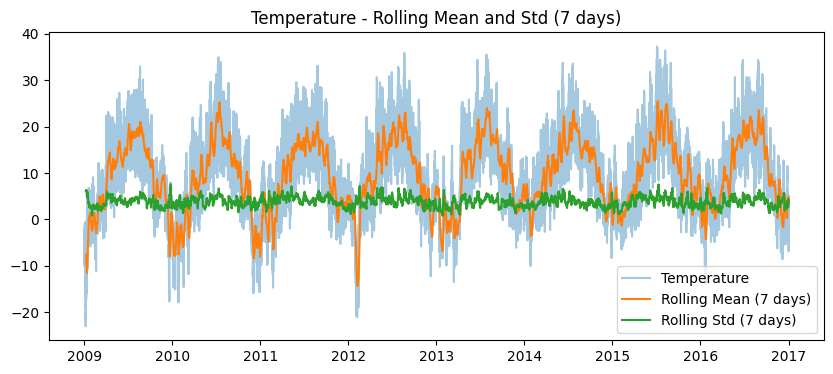

In [14]:
# Rolling mean and std for temperature (7-day window)
w = 7 * 24 * 6  # 7 days with 10-min data
t = df.set_index("Date Time")["T (degC)"]

roll_mean = t.rolling(w).mean()
roll_std = t.rolling(w).std()

plt.figure(figsize=(10, 4))
plt.plot(t, alpha=0.4, label="Temperature")
plt.plot(roll_mean, label="Rolling Mean (7 days)")
plt.plot(roll_std, label="Rolling Std (7 days)")
plt.title("Temperature - Rolling Mean and Std (7 days)")
plt.legend()
plt.show()

### 4.2.2 Preview of Hourly Resampling

In [15]:
feature_keys = [
    "p (mbar)", "T (degC)", "Tpot (K)", "Tdew (degC)", "rh (%)",
    "VPmax (mbar)", "VPact (mbar)", "VPdef (mbar)", "sh (g/kg)",
    "H2OC (mmol/mol)", "rho (g/m**3)", "wv (m/s)", "max. wv (m/s)", "wd (deg)"
]

df_hourly = (
    df.set_index("Date Time")[feature_keys]
      .resample("1h")   # <- lowercase h
      .mean()
      .reset_index()
)

print("Hourly shape:", df_hourly.shape)
display(df_hourly.head())

Hourly shape: (70129, 15)


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,2009-01-01 00:00:00,996.528000,-8.304000,265.118000,-9.120000,93.780000,3.260000,3.058000,0.202000,1.910000,3.068000,1309.196000,0.520000,1.002000,174.460000
1,2009-01-01 01:00:00,996.525000,-8.065000,265.361667,-8.861667,93.933333,3.323333,3.121667,0.201667,1.951667,3.133333,1307.981667,0.316667,0.711667,172.416667
2,2009-01-01 02:00:00,996.745000,-8.763333,264.645000,-9.610000,93.533333,3.145000,2.940000,0.201667,1.836667,2.950000,1311.816667,0.248333,0.606667,196.816667
3,2009-01-01 03:00:00,996.986667,-8.896667,264.491667,-9.786667,93.200000,3.111667,2.898333,0.210000,1.811667,2.906667,1312.813333,0.176667,0.606667,157.083333
4,2009-01-01 04:00:00,997.158333,-9.348333,264.026667,-10.345000,92.383333,3.001667,2.775000,0.231667,1.733333,2.780000,1315.355000,0.290000,0.670000,150.093333


In [16]:
print("Hourly missing timestamps:", df_hourly["Date Time"].isna().sum())
print("NaNs per column (hourly):")
display(df_hourly.isna().sum())

Hourly missing timestamps: 0
NaNs per column (hourly):


Date Time           0
p (mbar)           88
T (degC)           88
Tpot (K)           88
Tdew (degC)        88
rh (%)             88
VPmax (mbar)       88
VPact (mbar)       88
VPdef (mbar)       88
sh (g/kg)          88
H2OC (mmol/mol)    88
rho (g/m**3)       88
wv (m/s)           90
max. wv (m/s)      91
wd (deg)           88
dtype: int64

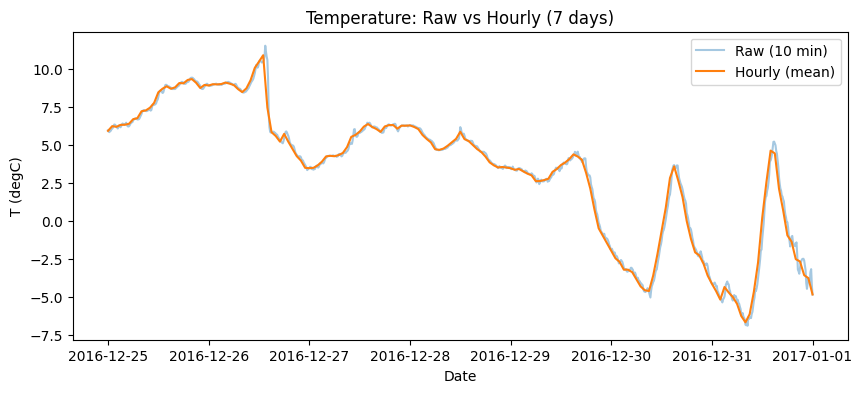

In [17]:
end = df["Date Time"].max()
start = end - pd.Timedelta(days=7)

raw_7d = df[(df["Date Time"] >= start) & (df["Date Time"] <= end)]
hourly_7d = df_hourly[(df_hourly["Date Time"] >= start) & (df_hourly["Date Time"] <= end)]

plt.figure(figsize=(10, 4))
plt.plot(raw_7d["Date Time"], raw_7d["T (degC)"], alpha=0.4, label="Raw (10 min)")
plt.plot(hourly_7d["Date Time"], hourly_7d["T (degC)"], label="Hourly (mean)")
plt.title("Temperature: Raw vs Hourly (7 days)")
plt.xlabel("Date")
plt.ylabel("T (degC)")
plt.legend()
plt.show()

### 4.3 Find rows (hours) with NaNs

In [18]:
na_rows = df_hourly[df_hourly.isna().any(axis=1)].copy()
print("Hourly rows with NaN:", len(na_rows))
display(na_rows.head(10))
display(na_rows.tail(10))

Hourly rows with NaN: 91


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
50226,2014-09-24 18:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50227,2014-09-24 19:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50228,2014-09-24 20:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50229,2014-09-24 21:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50230,2014-09-24 22:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50231,2014-09-24 23:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50232,2014-09-25 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50233,2014-09-25 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50234,2014-09-25 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50235,2014-09-25 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
68570,2016-10-28 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
68571,2016-10-28 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
68572,2016-10-28 04:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
68573,2016-10-28 05:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
68574,2016-10-28 06:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
68575,2016-10-28 07:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
68576,2016-10-28 08:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
68577,2016-10-28 09:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
68578,2016-10-28 10:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
68579,2016-10-28 11:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### 4.3.1 Remove Nan 

In [19]:
# Clean hourly data by dropping hours with no observations
df_hourly_clean = df_hourly.dropna().reset_index(drop=True)

print("Hourly before cleaning:", df_hourly.shape)
print("Hourly after cleaning: ", df_hourly_clean.shape)

# Sanity check
print("Remaining NaNs:", df_hourly_clean.isna().sum().sum())

Hourly before cleaning: (70129, 15)
Hourly after cleaning:  (70038, 15)
Remaining NaNs: 0


## 5. Data Preparation

### 5.1 Dataset Scope and Columns

#### 5.1.1 Define target, inputs and frequency

In [20]:
# Target variable
target_col = "T (degC)"

# Input features (Jena standard set)
feature_keys = ["T (degC)", "p (mbar)", "rh (%)", "wv (m/s)", "max. wv (m/s)", "wd (deg)"]

# Final working dataframe (hourly, clean)
df_work = df_hourly_clean[["Date Time"] + feature_keys].copy()

print("df_work shape:", df_work.shape)
display(df_work.head())

df_work shape: (70038, 7)


,Date Time,T (degC),p (mbar),rh (%),wv (m/s),max. wv (m/s),wd (deg)
0,2009-01-01 00:00:00,-8.304000,996.528000,93.780000,0.520000,1.002000,174.460000
1,2009-01-01 01:00:00,-8.065000,996.525000,93.933333,0.316667,0.711667,172.416667
2,2009-01-01 02:00:00,-8.763333,996.745000,93.533333,0.248333,0.606667,196.816667
3,2009-01-01 03:00:00,-8.896667,996.986667,93.200000,0.176667,0.606667,157.083333
4,2009-01-01 04:00:00,-9.348333,997.158333,92.383333,0.290000,0.670000,150.093333


#### 5.1.2 Sanity checks (no NaNs, correct dtypes)

In [21]:
print("NaNs per column:")
display(df_work.isna().sum())

print("\nDtypes:")
display(df_work.dtypes)

NaNs per column:


Date Time        0
T (degC)         0
p (mbar)         0
rh (%)           0
wv (m/s)         0
max. wv (m/s)    0
wd (deg)         0
dtype: int64


Dtypes:


Date Time        datetime64[us]
T (degC)                float64
p (mbar)                float64
rh (%)                  float64
wv (m/s)                float64
max. wv (m/s)           float64
wd (deg)                float64
dtype: object

#### 5.1.3 Confirm frequency is hourly

In [22]:
# Check time delta between consecutive rows
deltas = df_work["Date Time"].diff().dropna()
print("Most common deltas:")
display(deltas.value_counts().head(3))

Most common deltas:


Date Time
0 days 01:00:00    70034
0 days 16:00:00        1
0 days 04:00:00        1
Name: count, dtype: int64

#### 5.1.4 Set Date Time as index

In [23]:
df_work = df_work.set_index("Date Time")
print("Index type:", type(df_work.index))
display(df_work.head())

Index type: <class 'pandas.DatetimeIndex'>


,T (degC),p (mbar),rh (%),wv (m/s),max. wv (m/s),wd (deg)
Date Time,,,,,,
2009-01-01 00:00:00,-8.304000,996.528000,93.780000,0.520000,1.002000,174.460000
2009-01-01 01:00:00,-8.065000,996.525000,93.933333,0.316667,0.711667,172.416667
2009-01-01 02:00:00,-8.763333,996.745000,93.533333,0.248333,0.606667,196.816667
2009-01-01 03:00:00,-8.896667,996.986667,93.200000,0.176667,0.606667,157.083333
2009-01-01 04:00:00,-9.348333,997.158333,92.383333,0.290000,0.670000,150.093333


### 5.2 Temporal Split (Train / Validation / Test)

#### 5.2.1 Split Proportions

In [24]:
# Split ratios
train_ratio = 0.70
val_ratio   = 0.15
test_ratio  = 0.15

n_total = len(df_work)
n_train = int(n_total * train_ratio)
n_val   = int(n_total * val_ratio)

print("Total samples:", n_total)
print("Train size:", n_train)
print("Val size:", n_val)
print("Test size:", n_total - n_train - n_val)

Total samples: 70038
Train size: 49026
Val size: 10505
Test size: 10507


#### 5.2.2 Criar os conjuntos (contíguos no tempo)

In [25]:
df_train = df_work.iloc[:n_train]
df_val   = df_work.iloc[n_train:n_train + n_val]
df_test  = df_work.iloc[n_train + n_val:]

print("Train period:", df_train.index.min(), "->", df_train.index.max())
print("Val period:  ", df_val.index.min(),   "->", df_val.index.max())
print("Test period: ", df_test.index.min(),  "->", df_test.index.max())

print("\nShapes:")
print("Train:", df_train.shape)
print("Val:  ", df_val.shape)
print("Test: ", df_test.shape)

Train period: 2009-01-01 00:00:00 -> 2014-08-05 17:00:00
Val period:   2014-08-05 18:00:00 -> 2015-10-18 04:00:00
Test period:  2015-10-18 05:00:00 -> 2017-01-01 00:00:00

Shapes:
Train: (49026, 6)
Val:   (10505, 6)
Test:  (10507, 6)


#### 4.2.3 Visual target over splits

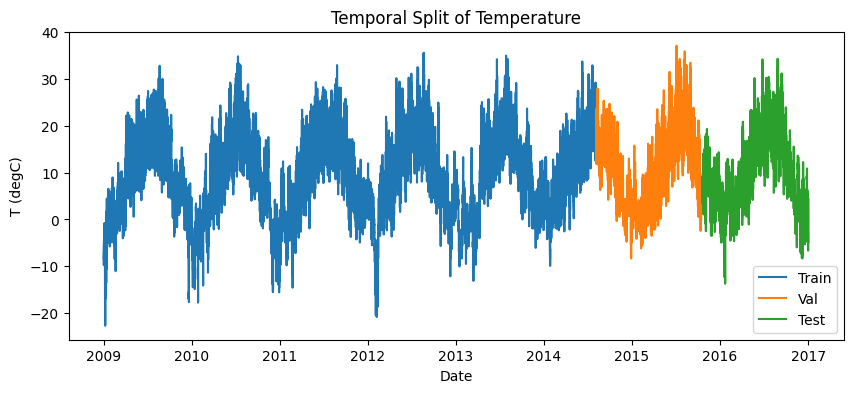

In [26]:
plt.figure(figsize=(10, 4))
plt.plot(df_train.index, df_train[target_col], label="Train")
plt.plot(df_val.index,   df_val[target_col],   label="Val")
plt.plot(df_test.index,  df_test[target_col],  label="Test")
plt.title("Temporal Split of Temperature")
plt.xlabel("Date")
plt.ylabel("T (degC)")
plt.legend()
plt.show()

### 5.3 Feature Engineering

In [27]:
def add_time_features(df_in):
    df = df_in.copy()

    # time parts
    hour = df.index.hour
    doy = df.index.dayofyear

    # cyclical encoding
    df["hour_sin"] = np.sin(2 * np.pi * hour / 24)
    df["hour_cos"] = np.cos(2 * np.pi * hour / 24)

    df["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
    df["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)

    # wind direction is circular
    wd = df["wd (deg)"].astype(float)
    df["wd_sin"] = np.sin(2 * np.pi * wd / 360.0)
    df["wd_cos"] = np.cos(2 * np.pi * wd / 360.0)

    # drop original angular variable
    df.drop(columns=["wd (deg)"], inplace=True)

    return df

df_train_fe = add_time_features(df_train)
df_val_fe   = add_time_features(df_val)
df_test_fe  = add_time_features(df_test)

print(df_train_fe.shape, df_val_fe.shape, df_test_fe.shape)

(49026, 11) (10505, 11) (10507, 11)


## 5.4 Scaling

In [28]:
from sklearn.preprocessing import StandardScaler

# Choose features to scale (all columns)
feat_cols = df_train_fe.columns.tolist()

scaler = StandardScaler()
scaler.fit(df_train_fe[feat_cols])

train_scaled = scaler.transform(df_train_fe[feat_cols])
val_scaled   = scaler.transform(df_val_fe[feat_cols])
test_scaled  = scaler.transform(df_test_fe[feat_cols])

# Back to DataFrame (keep index)
df_train_s = pd.DataFrame(train_scaled, index=df_train_fe.index, columns=feat_cols)
df_val_s   = pd.DataFrame(val_scaled,   index=df_val_fe.index,   columns=feat_cols)
df_test_s  = pd.DataFrame(test_scaled,  index=df_test_fe.index,  columns=feat_cols)

print("NaNs after scaling:", df_train_s.isna().sum().sum(), df_val_s.isna().sum().sum(), df_test_s.isna().sum().sum())

NaNs after scaling: 0 0 0


## 5.5 Windowing (L=120, H=24)

In [29]:
from numpy.lib.stride_tricks import sliding_window_view

L = 120  # input window (hours)
H = 24   # forecast horizon (hours)

def make_windows(df_scaled, target_name, L, H):
    # Cast to float32 once here — avoids repeated float64→float32
    # conversion inside TensorFlow on every batch during training.
    data = df_scaled.values.astype(np.float32)
    target_idx = df_scaled.columns.get_loc(target_name)
    n_samples = len(data) - L - H

    # Build X windows fully vectorized using stride tricks — no Python loop.
    # sliding_window_view(data, L, axis=0) → (n-L+1, n_features, L)
    # transpose(0,2,1)                     → (n-L+1, L, n_features)
    # [:n_samples]                          → (n_samples, L, n_features)
    X = sliding_window_view(data, window_shape=L, axis=0).transpose(0, 2, 1)[:n_samples].copy()

    # Build y windows: target column only, H steps ahead of each X window.
    # sliding_window_view on target[L:] → (n-L-H+1, H), take [:n_samples]
    y = sliding_window_view(data[L:, target_idx], window_shape=H)[:n_samples].copy()

    return X, y

X_train, y_train = make_windows(df_train_s, target_col, L, H)
X_val,   y_val   = make_windows(df_val_s,   target_col, L, H)
X_test,  y_test  = make_windows(df_test_s,  target_col, L, H)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:  ", X_val.shape,   "y_val:  ", y_val.shape)
print("X_test: ", X_test.shape,  "y_test: ", y_test.shape)
print("dtype:", X_train.dtype)

X_train: (48882, 120, 11) y_train: (48882, 24)
X_val:   (10361, 120, 11) y_val:   (10361, 24)
X_test:  (10363, 120, 11) y_test:  (10363, 24)
dtype: float32


#### 5.5.1 Baseline: Persistence

In [30]:
# persistence: predict next 24 hours as last observed temperature in the input window
target_idx = df_test_s.columns.get_loc(target_col)

last_T = X_test[:, -1, target_idx]  # last temp in each window
y_pred_persist = np.repeat(last_T[:, None], y_test.shape[1], axis=1)

print(y_pred_persist.shape)

(10363, 24)


#### 5.5.2 Metrics

In [31]:
def eval_multihorizon(y_true, y_pred):
    mae = mean_absolute_error(y_true.reshape(-1), y_pred.reshape(-1))
    rmse = np.sqrt(mean_squared_error(y_true.reshape(-1), y_pred.reshape(-1)))
    return mae, rmse

mae_p, rmse_p = eval_multihorizon(y_test, y_pred_persist)
print("Persistence - MAE:", mae_p, "RMSE:", rmse_p)

Persistence - MAE: 0.3636612594127655 RMSE: 0.49213009454107043


#### 5.5.3 MAE by horizont

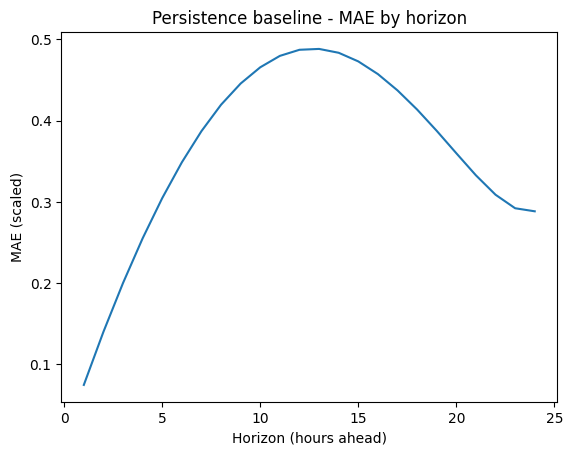

In [32]:
mae_by_h = np.mean(np.abs(y_test - y_pred_persist), axis=0)

plt.figure()
plt.plot(range(1, len(mae_by_h) + 1), mae_by_h)
plt.title("Persistence baseline - MAE by horizon")
plt.xlabel("Horizon (hours ahead)")
plt.ylabel("MAE (scaled)")
plt.show()

# 6. Model: Transformer v3 (PatchTST — pruner fix + focused search)

Changes from v2:
* Pruner fix: `min_resource=5` ensures every trial survives past the 5-epoch warmup before pruning kicks in
* Softer pruning: `reduction_factor=3` keeps top 50% per bracket instead of 33%
* Focused search space locked in patterns that won in both v1 and v2 (`huber1`, `adamw`, `noise=0.05`)
* max_epochs=60: gives the cosine schedule more room to converge


In [33]:
print("TF version:", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")
print("GPUs found:", gpus)

if gpus:
    # Avoid TF grabbing all GPU memory at once
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("GPU is available and memory growth is enabled.")
else:
    print("No GPU found. Training will run on CPU.")

TF version: 2.21.0
GPUs found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU is available and memory growth is enabled.


## 6.1 Setup: reproducibility

In [34]:
tf.random.set_seed(42)
np.random.seed(42)

H = y_train.shape[1]
L = X_train.shape[1]
n_features = X_train.shape[2]

## 6.2 Model Architecture and Hyperparameters

A Transformer-based forecasting model was implemented following a PatchTST-style design, adapted for multivariate time-series forecasting. Unlike the GRU model, which processes the full sequence recurrently, the Transformer learns temporal dependencies through self-attention mechanisms, allowing it to model both short- and long-range interactions in the input sequence.

The model receives an input window of length L = 120 hours and produces a direct forecast for the next H = 24 hours.

### Patch-based Input Representation

Instead of processing all time steps individually, the input sequence is divided into non-overlapping patches of fixed size. Each patch groups several consecutive time steps and is projected into a latent embedding space. This reduces the number of tokens processed by the attention layers and helps the model focus on higher-level temporal patterns while also reducing noise.

Given the configuration used here, the original input sequence is transformed into a sequence of patch embeddings, which are then used as tokens for the Transformer encoder.

### Positional Encoding

Since self-attention is permutation-invariant, sinusoidal positional encoding is added to the patch embeddings in order to preserve temporal order. This allows the model to distinguish between earlier and later parts of the input window.

### Transformer Encoder Blocks

The core of the model consists of several stacked Transformer encoder blocks. Each block contains:

* Multi-head self-attention, which enables the model to learn dependencies between different temporal regions of the input sequence;
* Feed-forward layers, which apply non-linear transformations to the learned representations;
* Residual connections and Layer Normalization, which improve optimisation stability and gradient flow.

The architecture uses a Pre-LayerNorm formulation, where normalization is applied before the attention and feed-forward sublayers. This design is known to improve training stability in deeper Transformer models.

### Output Representation

After the encoder blocks, the representation of the last patch token is selected and passed to the prediction head. This representation is then mapped to the final forecast vector of length 24, corresponding to the full multi-step forecasting horizon.

An optional dense projection layer can also be included before the output layer, enabling additional non-linear transformations.

### Training Configuration

To stabilise optimisation, the model uses:

* gradient clipping
* optional Gaussian input noise
* configurable dropout
* optional Adam or AdamW optimisation
* selectable loss functions (MSE, MAE, or Huber)

In addition, training uses a warmup + cosine decay learning-rate schedule, where the learning rate first increases linearly during the warmup phase and then decreases smoothly following a cosine schedule. This strategy is particularly useful for Transformer models, which are often sensitive to learning-rate selection during the initial training stages.

In [35]:
class WarmupCosineSchedule(keras.optimizers.schedules.LearningRateSchedule):
    """Linear warmup for `warmup_steps`, then cosine decay to `min_lr`."""

    def __init__(self, base_lr, warmup_steps, total_steps, min_lr=1e-6):
        super().__init__()
        self.base_lr = base_lr
        self.warmup_steps = warmup_steps
        self.total_steps = total_steps
        self.min_lr = min_lr

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        warmup = self.base_lr * (step / tf.maximum(tf.cast(self.warmup_steps, tf.float32), 1.0))
        cos_decay = self.min_lr + 0.5 * (self.base_lr - self.min_lr) * (
            1.0 + tf.math.cos(
                np.pi * (step - self.warmup_steps)
                / tf.maximum(tf.cast(self.total_steps - self.warmup_steps, tf.float32), 1.0)
            )
        )
        return tf.where(step < self.warmup_steps, warmup, cos_decay)

    def get_config(self):
        return {
            "base_lr": self.base_lr,
            "warmup_steps": self.warmup_steps,
            "total_steps": self.total_steps,
            "min_lr": self.min_lr,
        }


def positional_encoding_sinusoidal(length, d_model):
    """Fixed sinusoidal positional encoding."""
    pos = tf.cast(tf.range(length)[:, tf.newaxis], tf.float32)
    dim = tf.cast(tf.range(d_model)[tf.newaxis, :], tf.float32)
    angles = pos / tf.pow(10000.0, (2.0 * (dim // 2)) / tf.cast(d_model, tf.float32))
    sin_part = tf.math.sin(angles[:, 0::2])
    cos_part = tf.math.cos(angles[:, 1::2])
    return tf.cast(tf.concat([sin_part, cos_part], axis=-1)[:, :d_model], tf.float32)


def build_transformer_model(
    L, n_features, H,
    d_model=64,
    n_heads=4,
    n_blocks=2,
    ff_dim=128,
    patch_size=8,
    dropout=0.1,
    dense_units=0,
    dense_activation="relu",
    learning_rate=1e-3,
    clipnorm=1.0,
    optimizer_name="adam",
    weight_decay=1e-5,
    loss_name="mse",
    gaussian_noise_std=0.0,
    warmup_epochs=5,
    max_epochs=60,
    steps_per_epoch=1,
):
    """
    PatchTST-style Transformer for multi-step time series forecasting.

    Key differences from v1:
      - Patch embedding: groups P consecutive timesteps → one token
        (L=120, P=8 → 15 tokens; reduces noise, strengthens attention)
      - Pre-LayerNorm: LN before attention/FFN (more stable gradients)
      - Last-token output: uses final patch repr instead of global avg pool
      - Warmup + cosine LR schedule built into the optimizer
    """
    d_model = (d_model // n_heads) * n_heads
    if d_model == 0:
        d_model = n_heads

    # Number of patches (truncate if L not divisible by patch_size)
    n_patches = L // patch_size
    effective_L = n_patches * patch_size  # may discard a few trailing timesteps

    inputs = keras.Input(shape=(L, n_features))   # (batch, L, n_features)
    x = inputs

    # Optional input noise
    if gaussian_noise_std and gaussian_noise_std > 0:
        x = layers.GaussianNoise(gaussian_noise_std)(x)

    # ── Patch embedding ────────────────────────────────────────────────────
    # Truncate to effective_L, then reshape to (batch, n_patches, patch_size * n_features)
    x = x[:, :effective_L, :]
    x = layers.Reshape((n_patches, patch_size * n_features))(x)

    # Project each patch to d_model
    x = layers.Dense(d_model)(x)                # (batch, n_patches, d_model)

    # Add sinusoidal positional encoding over patch positions
    pe = positional_encoding_sinusoidal(n_patches, d_model)
    x = x + pe[tf.newaxis, :, :]

    x = layers.Dropout(dropout)(x)

    # ── Transformer encoder blocks (Pre-LayerNorm) ─────────────────────────
    for _ in range(n_blocks):
        # Pre-LN Multi-Head Self-Attention
        x_norm = layers.LayerNormalization(epsilon=1e-6)(x)
        attn_out = layers.MultiHeadAttention(
            num_heads=n_heads,
            key_dim=d_model // n_heads,
            dropout=dropout,
        )(x_norm, x_norm)
        x = x + attn_out                       # residual

        # Pre-LN Feed-Forward Network
        x_norm = layers.LayerNormalization(epsilon=1e-6)(x)
        ff = layers.Dense(ff_dim, activation="relu")(x_norm)
        ff = layers.Dropout(dropout)(ff)
        ff = layers.Dense(d_model)(ff)
        x = x + ff                              # residual

    # Final LayerNorm (standard for pre-LN architectures)
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    # ── Last-token output (instead of GlobalAveragePooling) ────────────────
    x = x[:, -1, :]                             # (batch, d_model)

    # Optional dense head
    if dense_units and dense_units > 0:
        if dense_activation == "leaky_relu":
            x = layers.Dense(dense_units)(x)
            x = layers.LeakyReLU(negative_slope=0.1)(x)
        else:
            x = layers.Dense(dense_units, activation=dense_activation)(x)
        x = layers.Dropout(dropout)(x)

    outputs = layers.Dense(H)(x)                # (batch, H)
    model = keras.Model(inputs, outputs)

    # ── LR schedule: linear warmup + cosine decay ──────────────────────────
    total_steps = max_epochs * steps_per_epoch
    warmup_steps = warmup_epochs * steps_per_epoch
    lr_schedule = WarmupCosineSchedule(
        base_lr=learning_rate,
        warmup_steps=warmup_steps,
        total_steps=total_steps,
        min_lr=1e-6,
    )

    # Optimizer
    if optimizer_name.lower() == "adamw":
        opt = keras.optimizers.AdamW(
            learning_rate=lr_schedule,
            weight_decay=weight_decay,
            clipnorm=clipnorm,
        )
    else:
        opt = keras.optimizers.Adam(learning_rate=lr_schedule, clipnorm=clipnorm)

    # Loss
    if loss_name == "mae":
        loss = "mae"
    elif loss_name == "huber1":
        loss = keras.losses.Huber(delta=1.0)
    elif loss_name == "huber2":
        loss = keras.losses.Huber(delta=2.0)
    else:
        loss = "mse"

    model.compile(optimizer=opt, loss=loss, metrics=["mae"])
    return model


## 6.3 Training Wrapper and Callbacks

To support systematic experimentation across multiple hyperparameter configurations, a dedicated training wrapper function was implemented for the Transformer model. This function is responsible for building the model from a sampled configuration, training it on the training set, validating it on the validation set, and returning both the trained model and its best validation metrics.

A key aspect of the training procedure is that the Transformer model uses a warmup + cosine decay learning-rate schedule built directly into the optimiser. For this reason, the number of training steps per epoch is computed dynamically from the training set size and batch size, so that the learning-rate schedule is correctly defined for each configuration.

During training, EarlyStopping is used to monitor the validation loss and stop training when no further improvement is observed for several epochs. The best model weights are restored automatically, ensuring that the final model corresponds to the best validation performance achieved during training.

Unlike the GRU training pipeline, ReduceLROnPlateau is not used here, since the Transformer already relies on an explicit warmup-cosine learning-rate schedule. Combining both approaches would introduce conflicting learning-rate updates and could destabilise optimisation.

After training, the wrapper extracts the minimum validation loss and validation MAE reached during the training process. These metrics are then used to compare different Transformer configurations during hyperparameter optimisation.

This modular training procedure ensures that all Transformer configurations are trained under a consistent protocol, making performance comparisons across trials fair and reproducible.

In [36]:
def train_one_config(cfg, X_train, y_train, X_val, y_val, max_epochs=60, fit_verbose=0):
    # Compute steps_per_epoch for the LR schedule
    steps_per_epoch = int(np.ceil(len(X_train) / cfg["batch_size"]))

    model = build_transformer_model(
        L=L, n_features=n_features, H=H,
        d_model=cfg["d_model"],
        n_heads=cfg["n_heads"],
        n_blocks=cfg["n_blocks"],
        ff_dim=cfg["ff_dim"],
        patch_size=cfg["patch_size"],
        dropout=cfg["dropout"],
        dense_units=cfg["dense_units"],
        dense_activation=cfg["dense_activation"],
        learning_rate=cfg["lr"],
        clipnorm=cfg["clipnorm"],
        optimizer_name=cfg["optimizer"],
        weight_decay=cfg.get("weight_decay", 0.0),
        loss_name=cfg.get("loss_name", "mse"),
        gaussian_noise_std=cfg.get("gaussian_noise_std", 0.0),
        warmup_epochs=5,
        max_epochs=max_epochs,
        steps_per_epoch=steps_per_epoch,
    )

    callbacks = [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
    ]
    # Note: we do NOT use ReduceLROnPlateau because the warmup+cosine schedule
    # already handles LR decay. Using both would cause conflicts.

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=max_epochs,
        batch_size=cfg["batch_size"],
        verbose=fit_verbose,
        callbacks=callbacks,
    )

    best_val_loss = float(np.min(history.history["val_loss"]))
    best_val_mae  = float(np.min(history.history["val_mae"]))
    return model, history, best_val_loss, best_val_mae


## 6.4 Hyperparameter Optimisation with Optuna

Hyperparameter optimisation for the Transformer model was performed using Optuna, following the same general optimisation framework adopted for the GRU experiments. However, in this case the search space was made more focused, based on insights obtained from earlier Transformer experiments.

A custom pruning callback was implemented to report the validation loss to Optuna at the end of each training epoch. This allowed unpromising trials to be terminated early, reducing computational cost and accelerating the optimisation process.

The optimisation objective minimises the validation loss, while the corresponding validation MAE is also recorded for later analysis. During the search, the best-performing model, configuration, and training history are stored whenever a new minimum validation loss is found.

### Focused Search Strategy

Unlike the broader search space used in the GRU experiments, the Transformer search was restricted to the most relevant architectural and training parameters. Some design choices were fixed based on previous empirical findings:

* Optimizer: AdamW  
* Loss function: Huber loss (δ = 1)  
* Gaussian input noise: 0.05  

These parameters were kept fixed because they consistently produced strong results in previous experiments. The optimisation was therefore concentrated on the remaining parameters that most directly affect Transformer behaviour, such as:

* number of attention heads,
* embedding dimension,
* number of encoder blocks,
* feed-forward dimension,
* patch size,
* dropout rate,
* dense projection layer,
* learning rate,
* batch size,
* gradient clipping,
* and weight decay.

### Architectural Constraints

A divisibility constraint was enforced to ensure compatibility between the embedding dimension and the number of attention heads. Specifically, the embedding size (`d_model`) was adjusted so that it is divisible by the number of heads, which is required for multi-head attention.

### Training and Pruning

Each trial was trained for up to 60 epochs, using EarlyStopping to restore the best model weights when validation performance stopped improving. In addition, the Optuna pruning callback allowed poorly performing trials to be stopped early based on validation loss progression.

This optimisation procedure allowed the search to focus on the most promising Transformer configurations while keeping the computational cost manageable.

In [37]:
class OptunaPruningCallback(keras.callbacks.Callback):
    """Reports val_loss to Optuna each epoch; prunes unpromising trials."""
    def __init__(self, trial):
        super().__init__()
        self.trial = trial

    def on_epoch_end(self, epoch, logs=None):
        val_loss = logs.get("val_loss")
        if val_loss is None:
            return
        self.trial.report(val_loss, epoch)
        if self.trial.should_prune():
            raise optuna.exceptions.TrialPruned()


best_holder = {"val_loss": np.inf, "model": None, "cfg": None, "history": None}


def objective(trial):

    # ── Focused search space based on v1 + v2 findings ───────────────────
    # Locked: adamw, huber1, noise=0.05 (won in both v1 and v2)
    n_heads     = trial.suggest_categorical("n_heads",     [2, 4, 8])
    d_model     = trial.suggest_categorical("d_model",     [64, 128, 256])
    n_blocks    = trial.suggest_int("n_blocks", 1, 4)
    ff_dim      = trial.suggest_categorical("ff_dim",      [128, 256, 512])
    patch_size  = trial.suggest_categorical("patch_size",  [4, 6, 8, 12])
    dropout     = trial.suggest_categorical("dropout",     [0.0, 0.1, 0.2, 0.3])
    dense_units = trial.suggest_categorical("dense_units", [0, 64, 128])
    dense_act   = trial.suggest_categorical("dense_activation", ["relu", "gelu", "elu", "leaky_relu"])
    lr          = trial.suggest_categorical("lr",          [2e-3, 1e-3, 5e-4, 3e-4, 1e-4])
    batch_size  = trial.suggest_categorical("batch_size",  [128, 256, 512])
    clipnorm    = trial.suggest_categorical("clipnorm",    [1.0, 2.0, 5.0])
    weight_decay= trial.suggest_categorical("weight_decay",[0.0, 1e-5, 1e-4])

    # Fixed based on previous experiments
    opt_name  = "adamw"
    loss_name = "huber1"
    noise_std = 0.05


    # ensure divisibility for multi-head attention
    d_model = max(n_heads, (d_model // n_heads) * n_heads)

    max_epochs = 60
    steps_per_epoch = int(np.ceil(len(X_train) / batch_size))


    cfg = dict(
        d_model=d_model,
        n_heads=n_heads,
        n_blocks=n_blocks,
        ff_dim=ff_dim,
        patch_size=patch_size,
        dropout=dropout,
        dense_units=dense_units,
        dense_activation=dense_act,
        lr=lr,
        batch_size=batch_size,
        clipnorm=clipnorm,
        optimizer=opt_name,
        weight_decay=weight_decay,
        loss_name=loss_name,
        gaussian_noise_std=noise_std,
    )


    model = build_transformer_model(
        L=L,
        n_features=n_features,
        H=H,
        d_model=d_model,
        n_heads=n_heads,
        n_blocks=n_blocks,
        ff_dim=ff_dim,
        patch_size=patch_size,
        dropout=dropout,
        dense_units=dense_units,
        dense_activation=dense_act,
        learning_rate=lr,
        clipnorm=clipnorm,
        optimizer_name=opt_name,
        weight_decay=weight_decay,
        loss_name=loss_name,
        gaussian_noise_std=noise_std,
        warmup_epochs=5,
        max_epochs=max_epochs,
        steps_per_epoch=steps_per_epoch,
    )


    callbacks = [

        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=10,
            restore_best_weights=True
        ),


        OptunaPruningCallback(trial),
    ]


    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=max_epochs,
        batch_size=batch_size,
        verbose=0,
        callbacks=callbacks,
    )


    best_val_loss = float(np.min(history.history["val_loss"]))
    best_val_mae  = float(np.min(history.history["val_mae"]))


    if best_val_loss < best_holder["val_loss"]:
        best_holder["val_loss"] = best_val_loss
        best_holder["model"] = model
        best_holder["cfg"] = cfg
        best_holder["history"] = history


    trial.set_user_attr("val_mae", best_val_mae)

    return best_val_loss


## 6.5 Hyperparameter Optimisation Run

The Transformer hyperparameter optimisation was executed using Optuna with a TPE sampler and a Hyperband pruning strategy, following the same general experimental protocol adopted for the GRU model.

A total of 150 trials were launched during the optimisation process. Among these, 63 trials completed successfully, while 87 trials were pruned early. This means that approximately 58% of the trials were terminated before full training, showing that the pruning strategy substantially reduced computational cost by stopping configurations that were unlikely to outperform the current best model.

The best validation loss achieved during the search was 0.0354 (scaled MSE). The optimisation process converged relatively early, and after the best configuration was found, most subsequent trials produced validation losses in a narrow range close to the best value. This suggests that the search successfully identified a stable region of the Transformer hyperparameter space.

In addition, the average duration of completed trials was approximately 24 seconds, indicating that the Transformer architecture remained computationally efficient despite the use of self-attention and patch-based representations.

| Metric | Value |
|--------|-------|
| Total trials | 150 |
| Completed trials | 63 |
| Pruned trials | 87 |
| Pruned proportion | 58.0% |
| Best validation loss | 0.0354 |
| Optimisation method | TPE (Bayesian) |
| Pruning strategy | Hyperband |
| Mean completed trial duration | 24.0 s |

**Table 21** - Summary of the Transformer Hyperparameter Optimisation Run

### 6.5.1 Best Transformer Configuration

The best-performing Transformer configuration was obtained in trial 41, achieving a validation loss of 0.0354 and a validation MAE of 0.1985.

This configuration corresponds to a relatively compact PatchTST-style Transformer, with a small embedding dimension, a single encoder block, and a moderate patch size. The model also includes a dense projection layer before the output, which increases its capacity to model non-linear relationships before generating the final 24-hour forecast vector.

The full set of hyperparameters for the best Transformer configuration is shown in Table X.

| Hyperparameter | Best Value |
|----------------|------------|
| Trial | 41 |
| best_val_loss | 0.0354 |
| best_val_mae | 0.1985 |
| train_time_sec | 31.0 |
| n_heads | 2 |
| d_model | 64 |
| n_blocks | 1 |
| ff_dim | 128 |
| patch_size | 6 |
| dropout | 0.1 |
| dense_units | 128 |
| dense_activation | elu |
| learning_rate | 0.002 |
| batch_size | 512 |
| clipnorm | 2.0 |
| optimizer | AdamW (fixed) |
| weight_decay | 1e-5 |
| loss_name | Huber (fixed) |
| gaussian_noise_std | 0.05 (fixed) |

**Table 22** - Best Transformer Configuration

### 6.5.2 Analysis of Hyperparameter Trials

Beyond identifying the best-performing configuration, it is important to analyse how different hyperparameter choices influenced Transformer performance.

A clear pattern emerges across the top-performing trials. Most of the best models share a compact architecture, typically with:

* 2 attention heads
* d_model = 64
* 1 encoder block
* ff_dim = 128 or 256
* patch sizes of 4 or 6
* dense_units = 128
* batch size = 512
* clipnorm = 2.0

This consistency suggests that the optimisation process converged to a stable and well-defined region of the hyperparameter space.

### Model Depth

The best-performing configurations consistently used only one encoder block. This indicates that, for this forecasting task, increasing Transformer depth was not necessary to achieve strong performance. Deeper models likely introduced additional complexity without corresponding gains in predictive accuracy.

### Embedding Size and Attention Heads

Smaller embedding sizes, particularly d_model = 64, performed well across many trials. Similarly, 2 attention heads appeared frequently among the strongest configurations. This suggests that a lightweight attention mechanism was sufficient to capture the relevant temporal interactions in the patched input sequence.

### Patch Size

The best results were obtained with patch sizes of 4 or 6, indicating that relatively short temporal patches provide a good balance between temporal resolution and noise reduction. Larger patch sizes tended to appear less often among the top-performing models.

### Dropout and Regularisation

Transformer configurations with low or moderate dropout generally performed best. The optimal trial used dropout = 0.1, suggesting that a small amount of regularisation was beneficial, unlike the GRU experiments where dropout was not necessary.

### Learning Rate and Batch Size

The best Transformer model used a comparatively high learning rate (0.002) combined with a large batch size (512). This is consistent with the use of the warmup-cosine learning-rate schedule, which stabilises training even when the base learning rate is relatively large.

Taken together, the optimisation results indicate that the Transformer performed best when configured as a small, efficient PatchTST-style model, rather than as a large and deep attention architecture.

| Rank | Trial | Val Loss | Val MAE | Time (s) | Heads | d_model | Blocks | FF Dim | Patch | Dropout | Dense | Act | LR | Batch | Clipnorm | Weight Decay |
|------|-------|----------|---------|----------|-------|---------|--------|--------|-------|---------|-------|-----|----|-------|----------|--------------|
| 1 | trial_41  | 0.0354 | 0.1985 | 31.0 | 2 | 64  | 1 | 128 | 6 | 0.1 | 128 | elu  | 0.002  | 512 | 2.0 | 1e-5 |
| 2 | trial_97  | 0.0364 | 0.2025 | 21.0 | 2 | 64  | 1 | 256 | 4 | 0.0 | 128 | relu | 0.0005 | 512 | 2.0 | 1e-5 |
| 3 | trial_36  | 0.0365 | 0.2018 | 28.6 | 2 | 128 | 1 | 128 | 6 | 0.1 | 128 | elu  | 0.002  | 512 | 2.0 | 1e-5 |
| 4 | trial_64  | 0.0365 | 0.2017 | 23.7 | 2 | 64  | 1 | 128 | 4 | 0.0 | 128 | relu | 0.001  | 512 | 2.0 | 0.0 |
| 5 | trial_83  | 0.0367 | 0.2017 | 21.8 | 2 | 256 | 1 | 128 | 4 | 0.0 | 128 | relu | 0.001  | 512 | 2.0 | 0.0 |
| 6 | trial_46  | 0.0367 | 0.2033 | 22.7 | 2 | 64  | 1 | 128 | 6 | 0.0 | 128 | elu  | 0.001  | 512 | 2.0 | 1e-5 |
| 7 | trial_70  | 0.0368 | 0.2010 | 22.9 | 2 | 256 | 1 | 128 | 4 | 0.0 | 128 | relu | 0.001  | 512 | 2.0 | 0.0 |
| 8 | trial_101 | 0.0368 | 0.2035 | 20.2 | 2 | 64  | 1 | 256 | 4 | 0.0 | 128 | relu | 0.0005 | 512 | 2.0 | 1e-5 |
| 9 | trial_128 | 0.0369 | 0.2050 | 21.4 | 8 | 64  | 1 | 512 | 4 | 0.0 | 128 | relu | 0.001  | 256 | 2.0 | 0.0 |
| 10 | trial_112 | 0.0369 | 0.2018 | 23.0 | 2 | 256 | 1 | 128 | 4 | 0.0 | 128 | relu | 0.001  | 512 | 2.0 | 0.0 |

**Table 23** - Top 10 trials Transformer

### 6.5.3 Interpretation of the Optimisation Behaviour

The optimisation behaviour of the Transformer differs slightly from that observed for the GRU model. While the GRU search converged toward moderately deep recurrent architectures, the Transformer search favoured smaller and simpler attention-based models.

This suggests that, for the present dataset and forecasting setup, the Transformer does not require many encoder layers or large embedding dimensions to achieve strong performance. Instead, a compact architecture with a small number of heads and a single encoder block appears sufficient to capture the relevant temporal patterns once the input sequence is transformed into temporal patches.

The pruning rate was also higher than in the GRU search, which indicates that Transformer performance was more sensitive to poor hyperparameter combinations. At the same time, the relatively low duration of the completed trials shows that the patch-based design remained computationally efficient.

[150/150] Trial #149 → PRUNED
  Complete: 63 | Pruned: 87 | Best so far: 0.0354


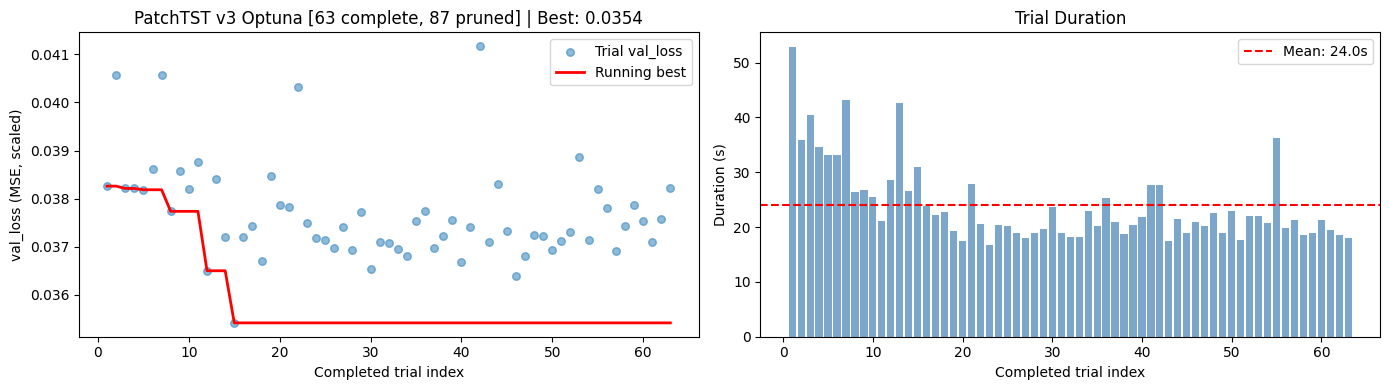


Optimization complete!
Best trial #41 — val_loss: 0.0354
Best params: {'n_heads': 2, 'd_model': 64, 'n_blocks': 1, 'ff_dim': 128, 'patch_size': 6, 'dropout': 0.1, 'dense_units': 128, 'dense_activation': 'elu', 'lr': 0.002, 'batch_size': 512, 'clipnorm': 2.0, 'weight_decay': 1e-05}


In [38]:
from IPython.display import clear_output

def progress_callback(study, trial):
    """Live chart redrawn after every trial (complete or pruned)."""
    clear_output(wait=True)
    completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
    pruned    = [t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED]
    n_done    = len(study.trials)

    state_str = ("PRUNED" if trial.state == optuna.trial.TrialState.PRUNED
                 else f"val_loss={trial.value:.4f}")
    print(f"[{n_done}/150] Trial #{trial.number} → {state_str}")
    if completed:
        print(f"  Complete: {len(completed)} | Pruned: {len(pruned)} | Best so far: {study.best_value:.4f}")

    if len(completed) < 2:
        return

    losses       = [t.value for t in completed]
    running_best = pd.Series(losses).cummin()
    durations    = [t.duration.total_seconds() for t in completed if t.duration]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    ax = axes[0]
    ax.scatter(range(1, len(losses) + 1), losses, alpha=0.5, s=30, label="Trial val_loss")
    ax.plot(range(1, len(losses) + 1), running_best, color="red", linewidth=2, label="Running best")
    ax.set_title(
        f"PatchTST v3 Optuna [{len(completed)} complete, {len(pruned)} pruned]"
        f" | Best: {study.best_value:.4f}"
    )
    ax.set_xlabel("Completed trial index")
    ax.set_ylabel("val_loss (MSE, scaled)")
    ax.legend()

    ax = axes[1]
    ax.bar(range(1, len(durations) + 1), durations, color="steelblue", alpha=0.7)
    if durations:
        ax.axhline(np.mean(durations), color="red", linestyle="--",
                   label=f"Mean: {np.mean(durations):.1f}s")
    ax.set_title("Trial Duration")
    ax.set_xlabel("Completed trial index")
    ax.set_ylabel("Duration (s)")
    ax.legend()

    plt.tight_layout()
    plt.show()


study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.HyperbandPruner(min_resource=5, max_resource=60, reduction_factor=3),
)

study.optimize(objective, n_trials=150, callbacks=[progress_callback])

print("\nOptimization complete!")
print(f"Best trial #{study.best_trial.number} — val_loss: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")


**Figure 88** - Transformer Hyperparameter Optimisation: Validation Loss Across Trials 

In [39]:
rows = []
for t in study.trials:
    if t.state != optuna.trial.TrialState.COMPLETE:
        continue
    row = {
        "name":           f"trial_{t.number:02d}",
        "best_val_loss":  t.value,
        "best_val_mae":   t.user_attrs.get("val_mae", np.nan),
        "train_time_sec": round(t.duration.total_seconds(), 1) if t.duration else np.nan,
        **t.params,
    }
    rows.append(row)

n_pruned = sum(1 for t in study.trials if t.state == optuna.trial.TrialState.PRUNED)
results_df = pd.DataFrame(rows).sort_values("best_val_loss").reset_index(drop=True)

print(f"Completed trials: {len(rows)} | Pruned: {n_pruned}")
display(results_df.head(10))

best_cfg_named = {**best_holder["cfg"], "name": f"trial_{study.best_trial.number:02d}"}
best = {
    "val_loss": best_holder["val_loss"],
    "model":    best_holder["model"],
    "history":  best_holder["history"],
    "cfg":      best_cfg_named,
}
best_transformer = best_holder["model"]


Completed trials: 63 | Pruned: 87


,name,best_val_loss,best_val_mae,train_time_sec,n_heads,d_model,n_blocks,ff_dim,patch_size,dropout,dense_units,dense_activation,lr,batch_size,clipnorm,weight_decay
0,trial_41,0.035420,0.198539,31.0,2,64,1,128,6,0.1,128,elu,0.0020,512,2.0,0.00001
1,trial_97,0.036394,0.202506,21.0,2,64,1,256,4,0.0,128,relu,0.0005,512,2.0,0.00001
2,trial_36,0.036502,0.201797,28.6,2,128,1,128,6,0.1,128,elu,0.0020,512,2.0,0.00001
3,trial_64,0.036532,0.201732,23.7,2,64,1,128,4,0.0,128,relu,0.0010,512,2.0,0.00000
4,trial_83,0.036690,0.201688,21.8,2,256,1,128,4,0.0,128,relu,0.0010,512,2.0,0.00000
5,trial_46,0.036703,0.203271,22.7,2,64,1,128,6,0.0,128,elu,0.0010,512,2.0,0.00001
6,trial_70,0.036802,0.201036,22.9,2,256,1,128,4,0.0,128,relu,0.0010,512,2.0,0.00000
7,trial_101,0.036808,0.203540,20.2,2,64,1,256,4,0.0,128,relu,0.0005,512,2.0,0.00001
8,trial_128,0.036923,0.204974,21.4,8,64,1,512,4,0.0,128,relu,0.0010,256,2.0,0.00000
9,trial_112,0.036936,0.201784,23.0,2,256,1,128,4,0.0,128,relu,0.0010,512,2.0,0.00000


## 6.6 Learning Curves of the Best Transformer Configuration

To better understand the training behaviour of the selected Transformer architecture, the evolution of the training and validation metrics was analysed across training epochs. The learning curves of the best configuration (trial 41) are presented in Figures X and Y.

### Training and Validation Loss

The loss curve shows a rapid decrease during the first few training epochs, indicating that the model quickly learns the main temporal structure of the data. After the initial learning phase, both training and validation loss gradually stabilise and converge toward similar values.

The relatively small gap between training and validation loss suggests that the model does not exhibit significant overfitting. Instead, the Transformer appears to generalise well to the validation data, maintaining stable performance throughout training.

### Training and Validation MAE

A similar pattern can be observed in the MAE curves. The error decreases sharply during the first epochs and then gradually converges toward a stable level around **0.20 MAE (scaled)**. The training and validation curves remain closely aligned, further confirming that the model maintains balanced learning dynamics without severe overfitting.

### Convergence Behaviour

Overall, the learning curves indicate that the PatchTST-style Transformer converges efficiently during training. The combination of **warmup-cosine learning rate scheduling**, **AdamW optimisation**, and **Huber loss** appears to provide stable optimisation dynamics.

The smooth convergence of both loss and MAE metrics suggests that the selected hyperparameter configuration leads to reliable training behaviour and effective learning of temporal patterns present in the meteorological time series.

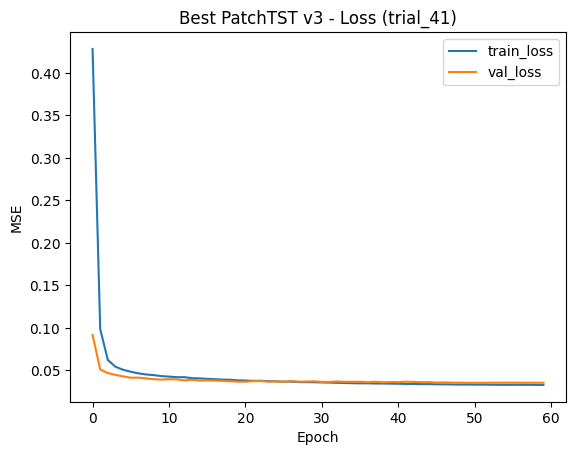

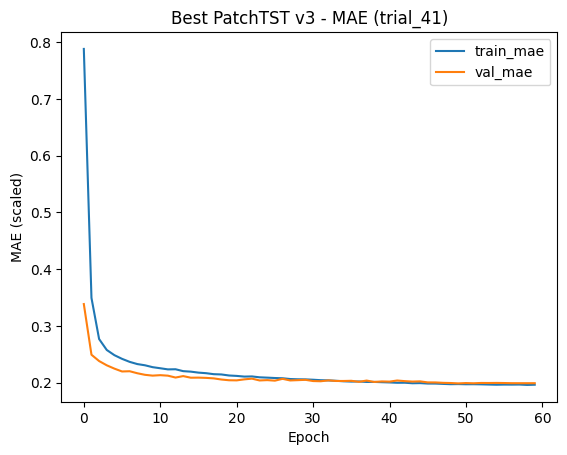

In [40]:
hist = best["history"].history

plt.figure()
plt.plot(hist["loss"], label="train_loss")
plt.plot(hist["val_loss"], label="val_loss")
plt.title(f"Best PatchTST v3 - Loss ({best['cfg']['name']})")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.show()

plt.figure()
plt.plot(hist["mae"], label="train_mae")
plt.plot(hist["val_mae"], label="val_mae")
plt.title(f"Best PatchTST v3 - MAE ({best['cfg']['name']})")
plt.xlabel("Epoch")
plt.ylabel("MAE (scaled)")
plt.legend()
plt.show()


## 6.7 Test Set Evaluation (Scaled Space)

After identifying the best-performing Transformer configuration during hyperparameter optimisation, the selected PatchTST model was evaluated on the independent test dataset. The evaluation was first performed in the scaled feature space, consistent with the representation used during model training.

Three standard regression metrics were computed: Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the coefficient of determination (R²). These metrics provide complementary perspectives on predictive performance, measuring absolute error magnitude, squared error sensitivity, and the proportion of variance explained by the model.

The PatchTST model achieved the following performance on the test set:

| Metric | Value |
|------|------|
| MAE (scaled) | 0.1968 |
| RMSE (scaled) | 0.2604 |
| R² | 0.9170 |

**Table 24** - PatchTST Test Set Performance in Scaled Feature Space

The relatively low error values and high R² indicate that the Transformer model is able to capture a substantial portion of the variability present in the temperature time series. An R² value above 0.91 suggests that the model explains more than 90% of the variance in the target variable, demonstrating strong predictive capability.

These results confirm that the PatchTST-style Transformer generalises well to unseen data and can effectively model the temporal dependencies present in the meteorological dataset.

In [41]:
y_pred_transformer_scaled = best_transformer.predict(X_test, verbose=0)

yt = y_test.reshape(-1)
yp = y_pred_transformer_scaled.reshape(-1)

mae  = mean_absolute_error(yt, yp)
rmse = np.sqrt(mean_squared_error(yt, yp))
r2   = r2_score(yt, yp)

print("TEST (scaled) - MAE:", mae, "RMSE:", rmse, "R2:", r2)


TEST (scaled) - MAE: 0.1967574805021286 RMSE: 0.2604426688882189 R2: 0.9169610142707825


## 6.8 Convert Predictions to °C

Since the model was trained using standardized input features, the predicted temperature values are initially produced in the scaled feature space. In order to obtain interpretable evaluation metrics, both the predictions and the ground-truth target values are transformed back to the original temperature scale (degrees Celsius).

The inverse transformation is applied using the mean and standard deviation learned by the scaler during preprocessing. Specifically, the transformation reverses the standardisation process applied to the target variable during training.

This step ensures that the resulting error metrics are expressed in physically meaningful units, allowing the forecasting accuracy of the model to be interpreted directly in terms of temperature differences.

In [42]:
def inverse_scale_target(y_scaled, scaler, feature_names, target_col):
    t_idx = feature_names.index(target_col)
    mean = scaler.mean_[t_idx]
    std  = scaler.scale_[t_idx]
    return y_scaled * std + mean

y_test_c = inverse_scale_target(y_test, scaler, feat_cols, target_col)
y_pred_c = inverse_scale_target(y_pred_transformer_scaled, scaler, feat_cols, target_col)


### 6.8.1 Metrics in °C

After converting both predictions and ground-truth values back to degrees Celsius, the model performance is evaluated using the Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the coefficient of determination (R²).

Evaluating the model in the original temperature scale provides a more intuitive interpretation of the forecasting accuracy. In this context, the MAE indicates the average magnitude of prediction errors in degrees Celsius, while the RMSE gives additional weight to larger deviations. The R² metric measures how well the model explains the variance present in the observed temperature series.

On the test set, the PatchTST Transformer achieves the following performance:

| Metric | Value |
|------|------|
| MAE (°C) | 1.70 |
| RMSE (°C) | 2.25 |
| R² | 0.917 |

**Table 25** - PatchTST Test Set Performance in Degrees Celsius

These results indicate that the model is able to produce accurate multi-step temperature forecasts, with average errors below two degrees Celsius. The high R² value also suggests that the model successfully captures most of the variability present in the temperature time series.

In [43]:
eps = 1e-6
yt = y_test_c.reshape(-1)
yp = y_pred_c.reshape(-1)

mae_c = mean_absolute_error(yt, yp)
rmse_c = np.sqrt(mean_squared_error(yt, yp))
r2_c = r2_score(yt, yp)

print("TEST (°C) - MAE:", mae_c, "RMSE:", rmse_c, "R2:", r2_c)

TEST (°C) - MAE: 1.7008773862886841 RMSE: 2.251406400151855 R2: 0.9169610133067123


## 6.9 MAE by Horizon

To further analyse the predictive performance of the PatchTST Transformer, the Mean Absolute Error (MAE) was computed separately for each forecasting horizon from 1 to 24 hours ahead. This horizon-wise evaluation provides insight into how prediction accuracy evolves as the forecast extends further into the future.

As expected in multi-step forecasting tasks, the prediction error gradually increases with the forecast horizon. Short-term predictions exhibit the lowest error levels, while longer horizons show slightly larger deviations due to the accumulation of uncertainty over time.

The results show that the model achieves an MAE of approximately 0.6 °C for the one-hour-ahead forecast, indicating very accurate short-term predictions. As the forecasting horizon increases, the error rises smoothly, reaching values slightly above 2.2 °C for the 24-hour horizon.

Despite this gradual increase, the overall error remains within a relatively narrow and acceptable range across the entire forecast window. This behaviour suggests that the Transformer model maintains stable predictive performance even for longer prediction horizons.

The smooth and monotonic increase of the MAE also indicates that the model does not exhibit sudden degradation in performance, which is often a sign of unstable multi-step forecasting. Instead, the PatchTST architecture appears to capture the temporal dynamics of the temperature series consistently across the full 24-hour prediction horizon.

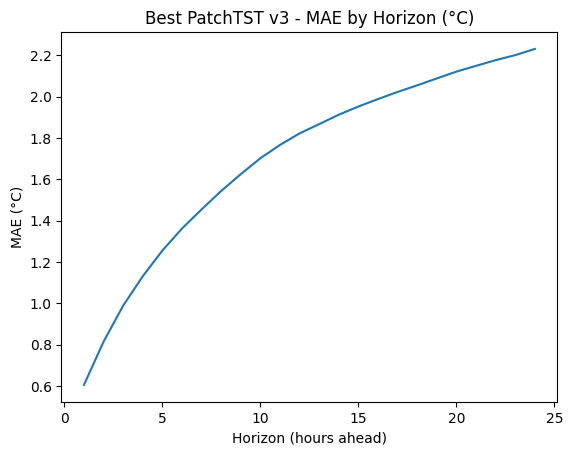

In [44]:
H = y_test.shape[1]
mae_by_h = np.mean(np.abs(y_test_c - y_pred_c), axis=0)

plt.figure()
plt.plot(range(1, H+1), mae_by_h)
plt.title("Best PatchTST v3 - MAE by Horizon (°C)")
plt.xlabel("Horizon (hours ahead)")
plt.ylabel("MAE (°C)")
plt.show()


**Figure 91** - PatchTST MAE by Forecasting Horizon (°C)

In [45]:
results_df.to_csv("transformer_v3_optuna_results.csv", index=False)

## 7. Overview of Transformer Hyperparameter Configurations

This section presents an overview of the hyperparameter configurations explored during the optimisation of the PatchTST Transformer model. Each configuration corresponds to a specific trial evaluated during the Optuna-based search process.

For every configuration, several architectural and training parameters were varied, including the number of attention heads, embedding dimension (`d_model`), number of Transformer encoder blocks, feed-forward network size, patch size, dropout rate, learning rate, and batch size.

In [46]:
display(results_df.head(10))     # top 10
display(results_df.tail(10))     # worst 10
print("Configs tested:", len(results_df))
print("Best val_loss:", results_df["best_val_loss"].min())
print("Best val_mae:", results_df["best_val_mae"].min())

,name,best_val_loss,best_val_mae,train_time_sec,n_heads,d_model,n_blocks,ff_dim,patch_size,dropout,dense_units,dense_activation,lr,batch_size,clipnorm,weight_decay
0,trial_41,0.035420,0.198539,31.0,2,64,1,128,6,0.1,128,elu,0.0020,512,2.0,0.00001
1,trial_97,0.036394,0.202506,21.0,2,64,1,256,4,0.0,128,relu,0.0005,512,2.0,0.00001
2,trial_36,0.036502,0.201797,28.6,2,128,1,128,6,0.1,128,elu,0.0020,512,2.0,0.00001
3,trial_64,0.036532,0.201732,23.7,2,64,1,128,4,0.0,128,relu,0.0010,512,2.0,0.00000
4,trial_83,0.036690,0.201688,21.8,2,256,1,128,4,0.0,128,relu,0.0010,512,2.0,0.00000
5,trial_46,0.036703,0.203271,22.7,2,64,1,128,6,0.0,128,elu,0.0010,512,2.0,0.00001
6,trial_70,0.036802,0.201036,22.9,2,256,1,128,4,0.0,128,relu,0.0010,512,2.0,0.00000
7,trial_101,0.036808,0.203540,20.2,2,64,1,256,4,0.0,128,relu,0.0005,512,2.0,0.00001
8,trial_128,0.036923,0.204974,21.4,8,64,1,512,4,0.0,128,relu,0.0010,256,2.0,0.00000
9,trial_112,0.036936,0.201784,23.0,2,256,1,128,4,0.0,128,relu,0.0010,512,2.0,0.00000


,name,best_val_loss,best_val_mae,train_time_sec,n_heads,d_model,n_blocks,ff_dim,patch_size,dropout,dense_units,dense_activation,lr,batch_size,clipnorm,weight_decay
53,trial_37,0.038409,0.208856,42.7,2,128,1,256,6,0.2,128,elu,0.002,128,1.0,0.00001
54,trial_47,0.038471,0.208178,19.2,4,64,1,128,6,0.0,128,elu,0.001,512,2.0,0.00001
55,trial_23,0.038576,0.208857,26.8,2,128,2,512,12,0.1,64,gelu,0.002,512,5.0,0.00010
56,trial_17,0.038626,0.210759,33.1,2,128,2,512,8,0.1,128,gelu,0.002,512,2.0,0.00010
57,trial_29,0.038771,0.209229,21.2,2,128,1,256,8,0.3,0,elu,0.002,512,1.0,0.00010
58,trial_115,0.038870,0.210741,22.1,2,64,1,128,12,0.0,128,relu,0.001,512,2.0,0.00000
59,trial_50,0.040320,0.214879,20.6,8,64,1,128,6,0.0,128,elu,0.001,256,2.0,0.00001
60,trial_18,0.040562,0.215631,43.1,2,128,4,128,4,0.1,64,relu,0.002,512,5.0,0.00010
61,trial_02,0.040573,0.216112,35.8,8,64,2,256,4,0.2,0,elu,0.001,512,2.0,0.00001
62,trial_86,0.041168,0.218353,27.6,2,64,1,128,6,0.3,128,relu,0.001,256,2.0,0.00000


Configs tested: 63
Best val_loss: 0.03541965410113335
Best val_mae: 0.19853942096233368


## 7.1 Histogram: Distribution of Validation Performance

To better understand the variability of model performance across the evaluated Transformer configurations, histograms were generated for both the best validation loss and the best validation MAE obtained during training.

The distribution of validation loss shows that the majority of configurations achieve values within a relatively narrow interval, concentrated around approximately 0.036–0.038 (scaled MSE). This clustering indicates that many hyperparameter combinations produce similar levels of predictive performance, suggesting that the model is relatively robust within this region of the search space.

Only a small number of configurations produce substantially higher validation losses, appearing as outliers on the right side of the distribution. These cases correspond to less effective architectural or optimisation settings identified during the hyperparameter search.

A similar pattern can be observed in the distribution of validation MAE. Most configurations fall within a narrow range around 0.20–0.21, while only a few trials exhibit noticeably higher error values.

These histograms indicate that the Transformer architecture demonstrates relatively stable behaviour across a wide range of hyperparameter settings. However, the presence of a few higher-error configurations highlights the importance of systematic hyperparameter optimisation in identifying the most effective model configuration.

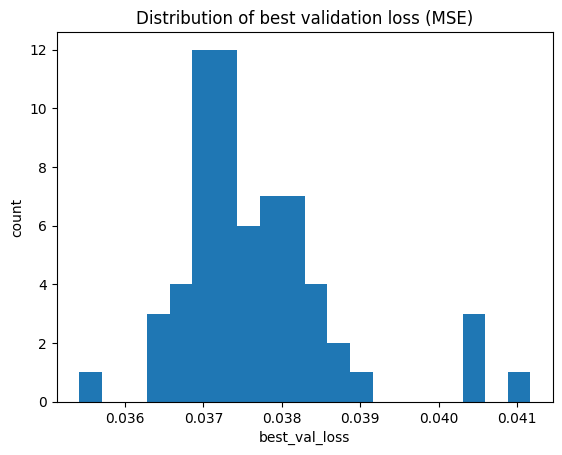

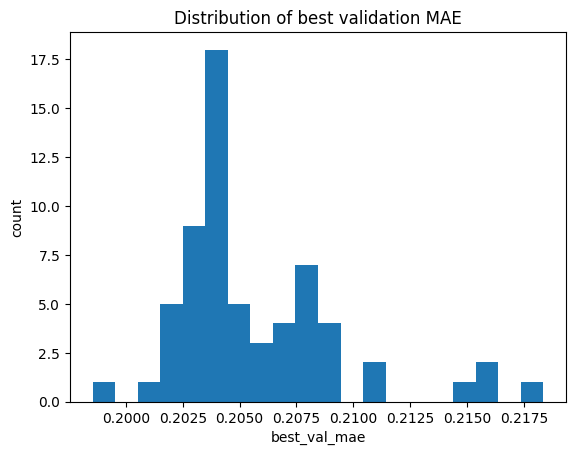

In [47]:
plt.figure()
plt.hist(results_df["best_val_loss"], bins=20)
plt.title("Distribution of best validation loss (MSE)")
plt.xlabel("best_val_loss")
plt.ylabel("count")
plt.show()

plt.figure()
plt.hist(results_df["best_val_mae"], bins=20)
plt.title("Distribution of best validation MAE")
plt.xlabel("best_val_mae")
plt.ylabel("count")
plt.show()

## 7.2 Hyperparameter Search Progress and Learning Rate Analysis

To better understand how the hyperparameter optimisation process evolved, two complementary visualisations are presented: the search progress across trials and the relationship between validation performance and the learning rate.

### Search Progress

The search progress plot illustrates how the validation loss evolves as successive configurations are evaluated during the Optuna optimisation process. Each point corresponds to a completed trial, while the red line represents the best validation loss obtained up to that point in the search.

The results show that the optimisation process quickly identifies several reasonably strong configurations during the early trials. A significant improvement is observed around trial 32, where the lowest validation loss is achieved. After this point, most subsequent trials produce performance values that fluctuate slightly around this optimum but do not significantly outperform the best configuration.

This behaviour suggests that the optimisation process successfully converged toward a stable region of the hyperparameter space, indicating that the selected search space contains multiple configurations with comparable predictive performance.

### Effect of Learning Rate

The boxplot analysis illustrates how the validation loss varies across different learning rate values explored during the hyperparameter search.

The results indicate that learning rates around 0.0005 and 0.001 tend to produce the most consistent performance, showing relatively low median validation losses and smaller variability across trials. In contrast, larger learning rates sometimes lead to higher variability and slightly worse validation performance.

This behaviour highlights the importance of selecting an appropriate learning rate when training Transformer-based models. Although the warmup–cosine learning rate schedule helps stabilise optimisation, the base learning rate still plays a crucial role in determining the convergence behaviour and final predictive accuracy of the model.

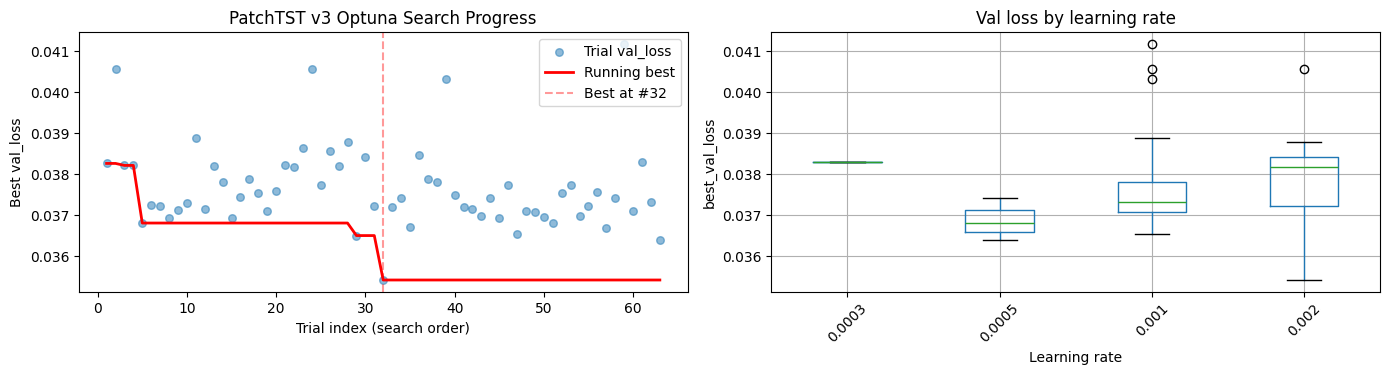

In [48]:
# Search progress chart
results_order = results_df.sort_values("name").reset_index(drop=True)
x = range(1, len(results_order) + 1)
running_best = results_order["best_val_loss"].cummin()
best_idx = int(results_order["best_val_loss"].idxmin()) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.scatter(x, results_order["best_val_loss"], alpha=0.5, s=30, label="Trial val_loss")
ax.plot(x, running_best, color="red", linewidth=2, label="Running best")
ax.axvline(best_idx, color="red", linestyle="--", alpha=0.4, label=f"Best at #{best_idx}")
ax.set_title("PatchTST v3 Optuna Search Progress")
ax.set_xlabel("Trial index (search order)")
ax.set_ylabel("Best val_loss")
ax.legend()

ax = axes[1]
results_df.boxplot(column="best_val_loss", by="lr", ax=ax)
ax.set_title("Val loss by learning rate")
plt.suptitle("")
ax.set_xlabel("Learning rate")
ax.set_ylabel("best_val_loss")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


**Figure 94** - PatchTST Optuna Search Progress (Validation Loss Across Trials)

## 7.3 Scatter: Performance vs Training Time

The scatter plot illustrates the relationship between training time and validation performance across the evaluated Transformer configurations.

Each point corresponds to a specific hyperparameter configuration tested during the optimisation process. The horizontal axis represents the total training time in seconds, while the vertical axis indicates the best validation loss achieved by that configuration.

The results show that most configurations cluster within a relatively narrow training-time range of approximately 18 to 25 seconds, while achieving validation losses between 0.036 and 0.038. This concentration suggests that the majority of Transformer configurations have similar computational cost and predictive performance.

Importantly, the plot indicates that longer training times do not necessarily lead to better predictive accuracy. Some configurations with longer training durations produce validation losses comparable to, or even worse than, models that train more quickly. This observation suggests that model complexity and training duration alone are not sufficient indicators of improved forecasting performance.

From a practical perspective, this analysis highlights that efficient Transformer configurations can achieve competitive predictive accuracy without requiring excessive computational cost. Such configurations represent favourable trade-offs between performance and training efficiency, which is particularly relevant in real-world forecasting applications.

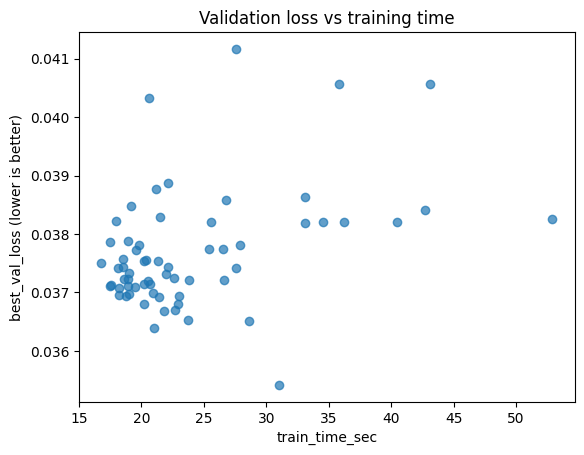

In [49]:
plt.figure()
plt.scatter(results_df["train_time_sec"], results_df["best_val_loss"], alpha=0.7)
plt.title("Validation loss vs training time")
plt.xlabel("train_time_sec")
plt.ylabel("best_val_loss (lower is better)")
plt.show()

**Figure 95** - Validation Loss vs Training Time for Transformer Configurations

## 7.4 Important Hyperparameters

To better understand how architectural choices influence the performance of the Transformer model, additional analyses were conducted focusing on key hyperparameters explored during the optimisation process. In particular, the impact of the number of encoder blocks on validation performance was examined.

### 7.4.1 Effect of the Number of Encoder Blocks

The boxplot above shows how the validation loss varies across models with different numbers of Transformer encoder blocks.

The results indicate that models with a single encoder block tend to achieve the lowest validation losses and also display relatively low variability across trials. This suggests that a shallow Transformer architecture is sufficient to capture the relevant temporal dependencies in the temperature time series.

Configurations with two encoder blocks generally produce slightly higher validation losses, while deeper architectures appear less frequently and do not provide clear performance improvements. In particular, models with three or four blocks show no consistent advantage over simpler configurations.

These observations suggest that increasing the depth of the Transformer does not necessarily improve forecasting accuracy for this task. Instead, a more compact architecture appears to provide a better balance between model capacity, training stability, and generalisation performance.

<Figure size 640x480 with 0 Axes>

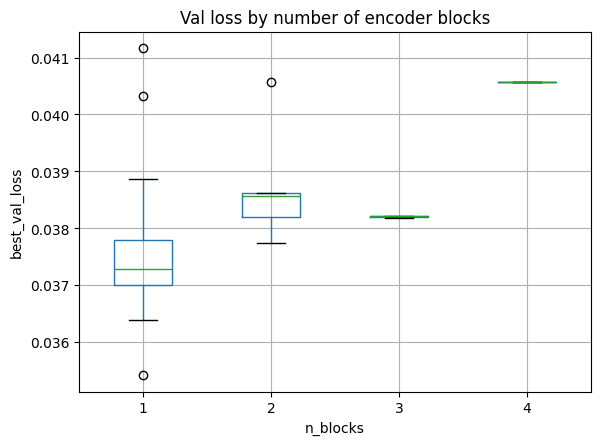

In [50]:
plt.figure()
results_df.boxplot(column="best_val_loss", by="n_blocks")
plt.title("Val loss by number of encoder blocks")
plt.suptitle("")
plt.xlabel("n_blocks")
plt.ylabel("best_val_loss")
plt.show()


**Figure 96** - Validation Loss by Number of Transformer Encoder Blocks

### 7.4.2 Effect of Patch Size

The boxplot above illustrates how validation performance varies across different patch sizes used in the PatchTST Transformer architecture. The patch size determines how many consecutive time steps are grouped together to form a single token before being processed by the Transformer encoder.

Smaller patch sizes, particularly 4 and 6 hours per token, tend to produce the lowest validation losses and show relatively consistent performance across trials. These configurations preserve more fine-grained temporal information while still benefiting from the noise reduction provided by patch-based representations.

In contrast, larger patch sizes such as 8 or 12 hours per token generally lead to slightly higher validation losses. This behaviour suggests that grouping too many time steps into a single patch may reduce the model’s ability to capture short-term variations in the temperature signal.

The results indicate that moderate patch sizes provide the best balance between temporal resolution and representation efficiency. Using patches that are too large may oversimplify the temporal structure of the input sequence, whereas smaller patches allow the Transformer to better model short-term dynamics in the time series.

<Figure size 640x480 with 0 Axes>

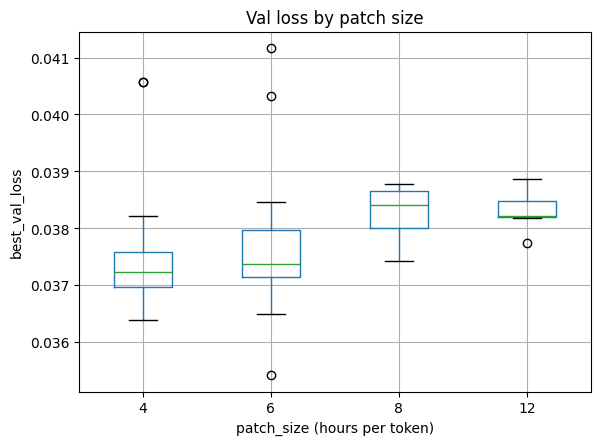

In [51]:
plt.figure()
results_df.boxplot(column="best_val_loss", by="patch_size")
plt.title("Val loss by patch size")
plt.suptitle("")
plt.xlabel("patch_size (hours per token)")
plt.ylabel("best_val_loss")
plt.show()


**Figure 97** - Validation Loss by Patch Size in the PatchTST Transformer 

### 7.4.3 Effect of Dropout

The boxplot above shows how validation performance varies across different dropout rates used during training. Dropout is a regularisation technique designed to reduce overfitting by randomly deactivating a fraction of neurons during each training iteration.

The results indicate that low or moderate dropout values tend to produce the best validation performance. In particular, configurations with dropout values of 0.0 or 0.1 generally achieve the lowest validation losses and show relatively stable behaviour across trials.

As the dropout rate increases, the validation loss tends to become slightly larger and more variable. Higher dropout values, such as 0.2 and 0.3, may remove too much information from intermediate representations, limiting the model’s ability to learn meaningful temporal patterns from the data.

These findings suggest that only mild regularisation is necessary for the Transformer architecture in this forecasting task. A small amount of dropout helps stabilise training and improve generalisation, while excessive regularisation can negatively affect the model’s predictive capacity.

This behaviour contrasts slightly with the GRU experiments presented earlier, where the best-performing configurations used no dropout at all, indicating that the recurrent architecture did not require explicit regularisation. In comparison, the Transformer architecture benefits from a small amount of regularisation, likely due to the higher flexibility and parameterisation introduced by the self-attention mechanism.

<Figure size 640x480 with 0 Axes>

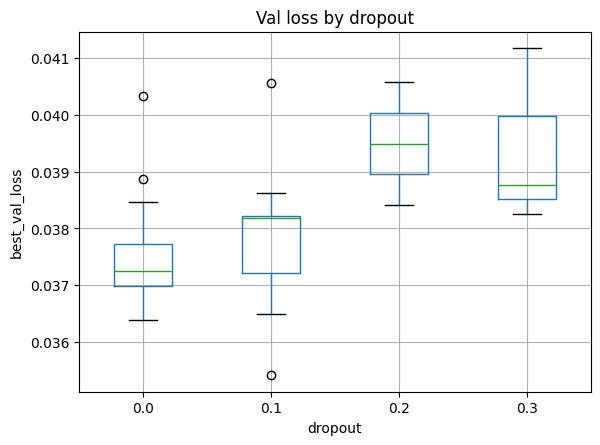

In [52]:
plt.figure()
results_df.boxplot(column="best_val_loss", by="dropout")
plt.title("Val loss by dropout")
plt.suptitle("")
plt.xlabel("dropout")
plt.ylabel("best_val_loss")
plt.show()

**Figure 98** - Validation Loss by Dropout Rate in the PatchTST Transformer

### 7.4.4 Effect of the Number of Attention Heads

The boxplot above illustrates how validation performance varies across different numbers of attention heads used in the Transformer architecture. The number of heads determines how many independent attention mechanisms operate in parallel when modelling relationships within the input sequence.

The results indicate that configurations using two attention heads tend to achieve the lowest validation losses and also exhibit relatively stable performance across trials. This suggests that a small number of attention heads is sufficient to capture the relevant temporal dependencies present in the temperature time series.

Increasing the number of heads to four leads to slightly higher validation losses, while configurations with eight attention heads show greater variability and generally worse performance. Using too many heads may increase model complexity without providing additional useful information for the forecasting task.

The results suggest that a lightweight attention mechanism is sufficient for this dataset, and that increasing the number of attention heads does not necessarily improve predictive performance. Instead, simpler attention structures appear to provide a better balance between model capacity and generalisation ability.

<Figure size 640x480 with 0 Axes>

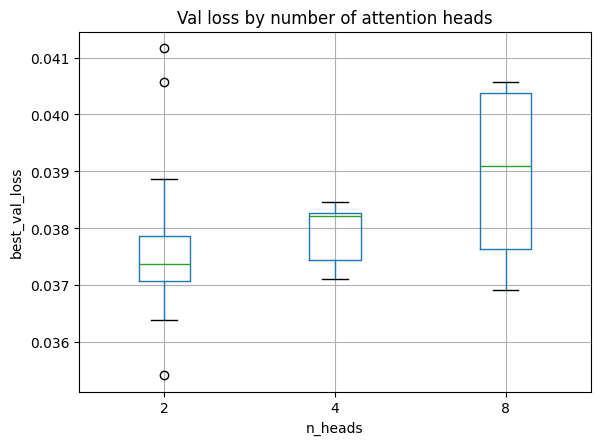

In [53]:
plt.figure()
results_df.boxplot(column="best_val_loss", by="n_heads")
plt.title("Val loss by number of attention heads")
plt.suptitle("")
plt.xlabel("n_heads")
plt.ylabel("best_val_loss")
plt.show()


**Figure 99** - Validation Loss by Number of Attention Heads in the PatchTST Transformer

### 7.4.5 Effect of the Embedding Dimension (d_model)

The boxplot above shows the relationship between the embedding dimension (`d_model`) and the validation loss obtained across different Transformer configurations. The parameter `d_model` determines the dimensionality of the vector representation used for each token processed by the Transformer encoder.

The results indicate that models with smaller embedding dimensions, particularly d_model = 64, tend to achieve the lowest validation losses and also exhibit relatively stable performance across trials. This suggests that a compact representation is sufficient to capture the relevant temporal patterns present in the temperature time series.

Increasing the embedding dimension to 128 or 256 does not lead to consistent improvements in predictive performance. In fact, larger embedding sizes often introduce slightly higher validation losses and greater variability between configurations. This behaviour may be explained by the increased number of parameters associated with larger embeddings, which can make optimisation more difficult and potentially lead to overfitting.

These findings suggest that a relatively small embedding dimension provides an effective balance between model capacity and training stability for this forecasting task. The results reinforce the observation that compact Transformer architectures are sufficient to model the temporal dynamics of the dataset.

<Figure size 640x480 with 0 Axes>

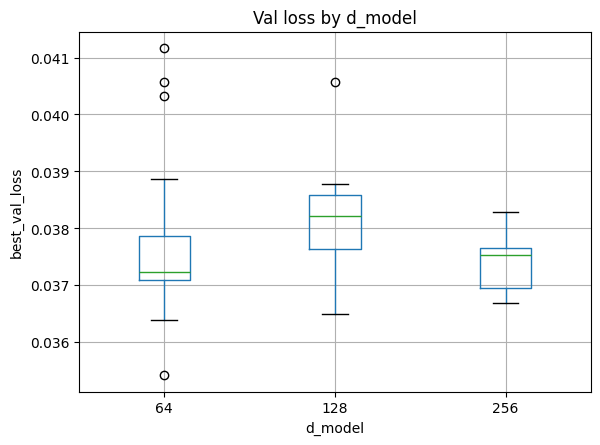

In [54]:
plt.figure()
results_df.boxplot(column="best_val_loss", by="d_model")
plt.title("Val loss by d_model")
plt.suptitle("")
plt.xlabel("d_model")
plt.ylabel("best_val_loss")
plt.show()


**Figure 100** - Validation Loss by Embedding Dimension (d_model) in the PatchTST Transformer

# 8. Horizon-wise Comparison: Baseline vs Best PatchTST v3 (°C)

To evaluate the effectiveness of the Transformer-based forecasting model, its performance is compared with a simple persistence baseline across the full 24-hour prediction horizon. The persistence model assumes that the future temperature will remain equal to the most recently observed value, serving as a commonly used reference in time series forecasting.

The figure presents the Mean Absolute Error (MAE) in degrees Celsius for each forecast horizon from 1 to 24 hours ahead. As expected, the persistence baseline performs reasonably well for very short horizons but its error increases rapidly as the forecast horizon grows. This behaviour reflects the inability of the baseline model to capture the evolving dynamics of the temperature signal over time.

In contrast, the PatchTST Transformer model maintains substantially lower errors across all horizons. While the error gradually increases with longer prediction horizons due to the accumulation of uncertainty, the increase is smooth and remains significantly below the baseline.

For example, while the persistence model reaches errors above 4 °C around the middle of the forecast horizon, the Transformer model maintains errors close to 2 °C even at longer horizons. This demonstrates that the Transformer architecture successfully learns temporal patterns and dependencies in the meteorological data, enabling it to produce more reliable multi-step forecasts.

Overall, the comparison confirms that the PatchTST model provides a clear improvement over the naive persistence baseline and is capable of capturing the underlying temporal dynamics of the temperature time series.

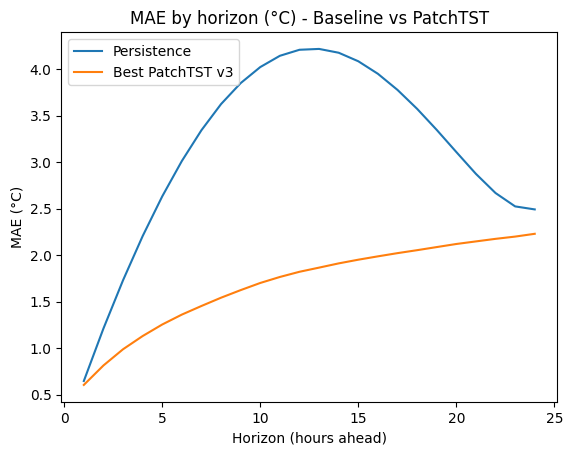

In [55]:
y_pred_persist_c = inverse_scale_target(y_pred_persist, scaler, feat_cols, target_col)

H = y_test.shape[1]
mae_h_p = np.mean(np.abs(y_test_c - y_pred_persist_c), axis=0)
mae_h_t = np.mean(np.abs(y_test_c - y_pred_c),         axis=0)

plt.figure()
plt.plot(range(1, H+1), mae_h_p, label="Persistence")
plt.plot(range(1, H+1), mae_h_t, label="Best PatchTST v3")
plt.title("MAE by horizon (°C) - Baseline vs PatchTST")
plt.xlabel("Horizon (hours ahead)")
plt.ylabel("MAE (°C)")
plt.legend()
plt.show()


**Figure 101** - Horizon‑Wise MAE Comparison: Persistence Baseline vs PatchTST (°C)

## 8.1 Error Distribution (Residuals) on Test (°C)

To further assess the predictive behaviour of the PatchTST Transformer model, the distribution of residuals on the test dataset was analysed. Residuals are defined as the difference between the true temperature values and the predicted values generated by the model.

The residual histogram appears approximately centred around zero, indicating that the model does not exhibit a strong systematic bias. In other words, the Transformer does not consistently overestimate or underestimate the temperature values across the test set.

The distribution also shows a relatively symmetric bell-shaped pattern, suggesting that positive and negative prediction errors occur with similar frequency. Most residuals are concentrated within a relatively narrow interval around zero, which indicates that the majority of predictions are close to the true observed temperatures.

The second figure presents the distribution of absolute prediction errors. As expected, the largest concentration of errors occurs at small values, with most predictions showing deviations of less than 2 °C. Larger errors appear less frequently and form a long but gradually decreasing tail.

These results confirm that the PatchTST model produces stable and unbiased forecasts, with most prediction errors remaining relatively small in magnitude. This behaviour is consistent with the quantitative evaluation metrics obtained earlier and further supports the reliability of the Transformer model for multi-step temperature forecasting.

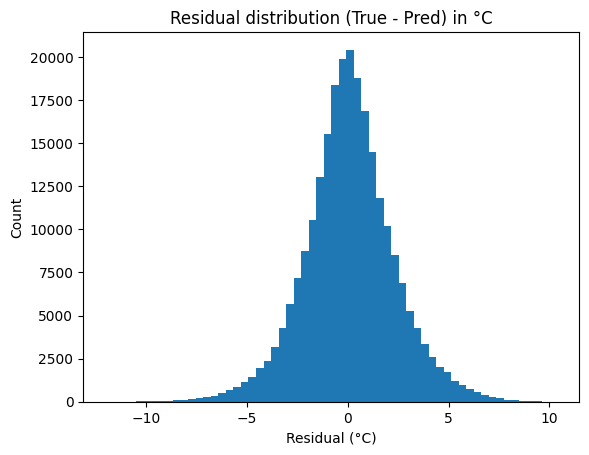

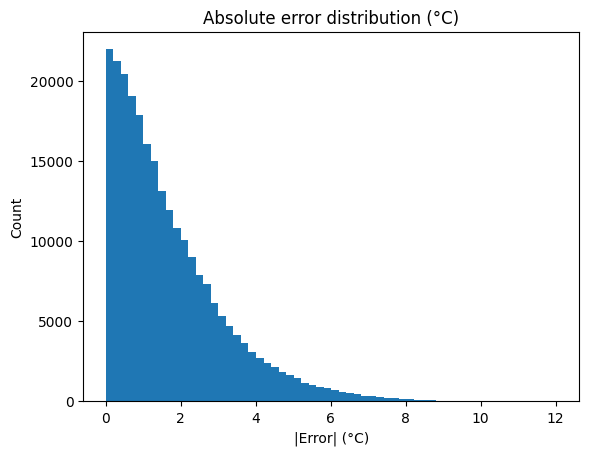

In [56]:
res = (y_test_c - y_pred_c).reshape(-1)

plt.figure()
plt.hist(res, bins=60)
plt.title("Residual distribution (True - Pred) in °C")
plt.xlabel("Residual (°C)")
plt.ylabel("Count")
plt.show()

# Absolute error distribution
abs_err = np.abs(res)
plt.figure()
plt.hist(abs_err, bins=60)
plt.title("Absolute error distribution (°C)")
plt.xlabel("|Error| (°C)")
plt.ylabel("Count")
plt.show()

## 8.2 Plot Actual vs Predicted for a Continuous Slice (h=1)

To visually assess the short-term forecasting capability of the PatchTST Transformer, a continuous segment of the test dataset is plotted comparing the true temperature values with the model's one-hour-ahead predictions.

The figure shows a one-week slice of the test period, allowing the temporal evolution of both the observed and predicted temperature signals to be inspected. The predicted curve closely follows the overall dynamics of the true temperature series, capturing both the upward and downward trends associated with the daily temperature cycle.

In particular, the Transformer model successfully reproduces the main peaks and troughs of the temperature signal, indicating that it has learned the dominant diurnal patterns present in the meteorological data. Although small deviations between the predicted and true values can be observed, the overall trajectories remain highly consistent.

Some slight smoothing of the predicted signal is visible around sharp transitions, which is common in neural forecasting models. This behaviour suggests that the model prioritises capturing the general structure of the temperature evolution rather than reproducing every short-term fluctuation exactly.

Overall, this visual inspection confirms that the PatchTST Transformer is capable of accurately tracking short-term temperature variations and producing reliable one-step-ahead forecasts.

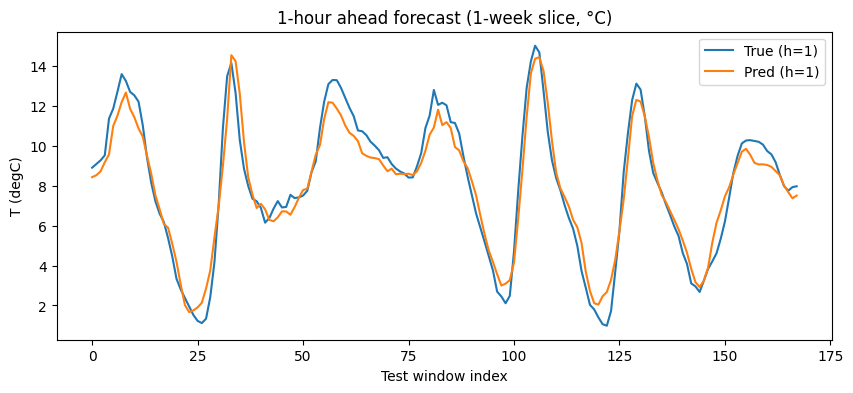

In [57]:
start = 0
n = 7 * 24  # 1 week of windows

y_true_1 = y_test_c[start:start+n, 0]
y_pred_1 = y_pred_c[start:start+n, 0]

plt.figure(figsize=(10,4))
plt.plot(y_true_1, label="True (h=1)")
plt.plot(y_pred_1, label="Pred (h=1)")
plt.title("1-hour ahead forecast (1-week slice, °C)")
plt.xlabel("Test window index")
plt.ylabel("T (degC)")
plt.legend()
plt.show()

**Figure 104** - Actual vs Predicted Temperature for a Continuous Test Slice (1-Hour Ahead Forecast) 

## 8.3 Plot 24-hour Trajectories for a Few Examples

To further analyse the behaviour of the Transformer model across the full forecasting horizon, several examples of 24-hour prediction trajectories from the test dataset are visualised. Each plot compares the sequence of predicted temperatures with the corresponding true observations over the entire forecast window.

These examples illustrate how the PatchTST Transformer performs when generating multi-step forecasts, where all 24 future values are predicted simultaneously from the input window.

Across the different cases shown, the predicted trajectories generally follow the overall shape of the true temperature evolution. The model successfully captures the main upward and downward trends associated with daily temperature cycles, demonstrating that it has learned meaningful temporal dependencies in the data.

As expected, deviations between predicted and true values become more noticeable toward the later forecast horizons. This behaviour is typical in multi-step forecasting, where prediction uncertainty accumulates as the model extrapolates further into the future.

In some cases, the predicted trajectories appear slightly smoother than the observed signal. This smoothing effect is common in neural forecasting models and reflects the model’s tendency to prioritise capturing the general structure of the temperature dynamics rather than reproducing every short-term fluctuation.

These examples confirm that the Transformer model is capable of generating coherent multi-step temperature forecasts while maintaining a realistic representation of the underlying temporal patterns.

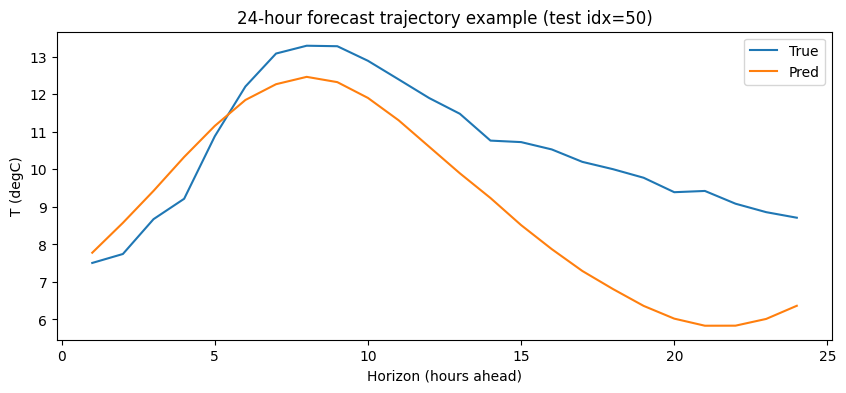

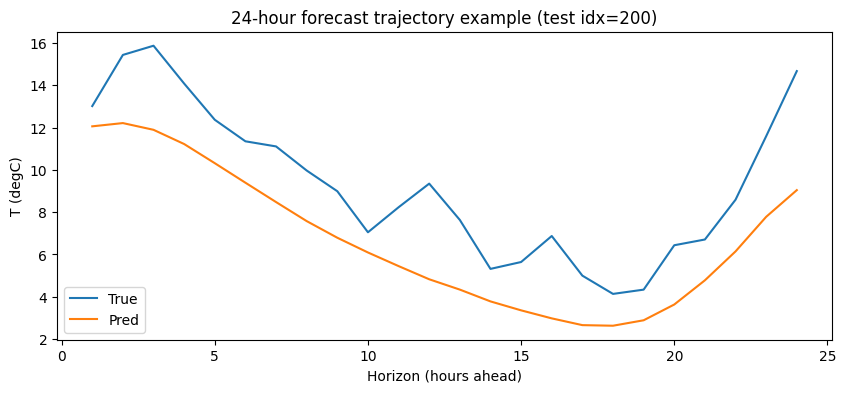

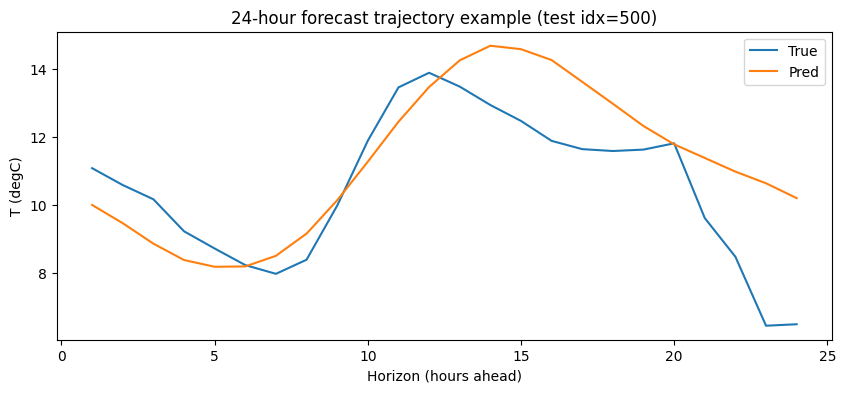

In [58]:
examples = [50, 200, 500]  # pick any indices within test

for i in examples:
    plt.figure(figsize=(10,4))
    plt.plot(range(1, H+1), y_test_c[i], label="True")
    plt.plot(range(1, H+1), y_pred_c[i], label="Pred")
    plt.title(f"24-hour forecast trajectory example (test idx={i})")
    plt.xlabel("Horizon (hours ahead)")
    plt.ylabel("T (degC)")
    plt.legend()
    plt.show()

# 9. Forecasting

Beyond evaluating predictive performance on historical data, an important objective of time series models is their ability to generate forecasts for future time periods. In practical applications, forecasting models are used to estimate upcoming values of the target variable based on the most recent observations available.

In this section, the trained PatchTST Transformer model is applied to generate temperature forecasts using the latest observations in the dataset. The objective is to simulate a realistic forecasting scenario in which the model produces predictions for the next 24 hours based on the most recent historical window.

## 9.1 Forecasting for 1 Hour

To ensure consistency with the training procedure, the same preprocessing steps are applied to the input data. The most recent input window is first constructed from the dataset, including all features used during training. These values are then transformed using the previously fitted scaler so that the input representation matches the scaled format used by the model.

The scaled input window is then provided to the trained Transformer model, which generates a sequence of predictions corresponding to the next 24 hours. Since the model outputs predictions in the scaled feature space, the results are converted back to the original temperature scale using the inverse transformation of the scaler.

Finally, the predicted temperatures are associated with their corresponding future timestamps and visualised both as a time series plot and as a tabular representation. This forecast provides an estimate of how the temperature is expected to evolve over the next day according to the trained PatchTST model.

| Date Time | T_forecast_degC |
|---|---|
| 2017-01-01 01:00 | -4.541 |
| 2017-01-01 02:00 | -5.162 |
| 2017-01-01 03:00 | -5.780 |
| 2017-01-01 04:00 | -6.097 |
| 2017-01-01 05:00 | -6.254 |
| 2017-01-01 06:00 | -6.023 |
| 2017-01-01 07:00 | -5.543 |
| 2017-01-01 08:00 | -4.687 |
| 2017-01-01 09:00 | -3.466 |
| 2017-01-01 10:00 | -2.203 |
| 2017-01-01 11:00 | -0.828 |
| 2017-01-01 12:00 | 0.519 |
| 2017-01-01 13:00 | 1.394 |
| 2017-01-01 14:00 | 1.977 |
| 2017-01-01 15:00 | 2.069 |
| 2017-01-01 16:00 | 1.844 |
| 2017-01-01 17:00 | 1.318 |
| 2017-01-01 18:00 | 0.831 |
| 2017-01-01 19:00 | 0.342 |
| 2017-01-01 20:00 | -0.027 |
| 2017-01-01 21:00 | -0.361 |
| 2017-01-01 22:00 | -0.620 |
| 2017-01-01 23:00 | -0.946 |
| 2017-01-02 00:00 | -1.386 |

**Table 26** - Forecasted Temperature Values for the Next 24 Hours (°C)

/home/ricarl/dev/iscte/taap_p3/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


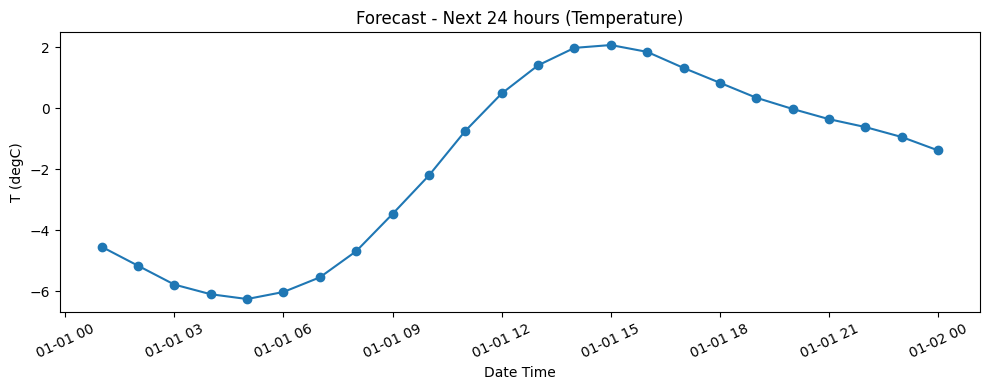

,Date Time,T_forecast_degC
0,2017-01-01 01:00:00,-4.541318
1,2017-01-01 02:00:00,-5.161893
2,2017-01-01 03:00:00,-5.780481
3,2017-01-01 04:00:00,-6.096701
4,2017-01-01 05:00:00,-6.253850
5,2017-01-01 06:00:00,-6.023166
6,2017-01-01 07:00:00,-5.543478
7,2017-01-01 08:00:00,-4.686991
8,2017-01-01 09:00:00,-3.465556
9,2017-01-01 10:00:00,-2.203391


,Date Time,T_forecast_degC
14,2017-01-01 15:00:00,2.068504
15,2017-01-01 16:00:00,1.843931
16,2017-01-01 17:00:00,1.318025
17,2017-01-01 18:00:00,0.830720
18,2017-01-01 19:00:00,0.341509
19,2017-01-01 20:00:00,-0.026872
20,2017-01-01 21:00:00,-0.360800
21,2017-01-01 22:00:00,-0.619767
22,2017-01-01 23:00:00,-0.945997
23,2017-01-02 00:00:00,-1.385585


In [ ]:
# Build last input window (L hours) from the end of the dataset
df_full = df_work.copy()  # df_work: hourly clean, index=Date Time, columns=features (unscaled)

# If you engineered features during training, apply the same here:
df_full_fe = add_time_features(df_full)

# Keep the same columns and order used in scaling/training
df_full_fe = df_full_fe[feat_cols].copy()

# Take last L rows
last_window = df_full_fe.iloc[-L:].copy()

# Scale
last_window_scaled = scaler.transform(last_window.values)

# Model input shape: (1, L, n_features)
X_last = last_window_scaled.reshape(1, L, len(feat_cols))

# Predict next 24h (scaled)
y_next24_scaled = best_transformer.predict(X_last, verbose=0)  # shape (1, 24)

# Inverse scale to °C
y_next24_c = inverse_scale_target(y_next24_scaled, scaler, feat_cols, target_col).flatten()

# Build future datetime index
last_time = df_full_fe.index[-1]
future_index_24 = pd.date_range(start=last_time + pd.Timedelta(hours=1), periods=H, freq="1h")

# Plot forecast
plt.figure(figsize=(10,4))
plt.plot(future_index_24, y_next24_c, marker="o")
plt.title("Forecast - Next 24 hours (Temperature)")
plt.xlabel("Date Time")
plt.ylabel("T (degC)")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

# Show as table
forecast_24h = pd.DataFrame({"Date Time": future_index_24, "T_forecast_degC": y_next24_c})
display(forecast_24h.head(10))
display(forecast_24h.tail(10))

**Figure 108** - 24-Hour Temperature Forecast Generated by the PatchTST Transformer Model (°C)

## 9.2 Five-Day Forecasting

To further demonstrate the practical forecasting capability of the trained PatchTST Transformer, a longer prediction horizon is generated by extending the forecast to five days (120 hours). Since the model is trained to predict a fixed horizon of 24 hours, a rolling forecasting strategy is used to iteratively produce predictions beyond the initial forecast window.

At each step, the model receives the most recent input window and predicts the next 24 hours. The predicted temperature values are then appended to the simulated time series and used as part of the input for the next prediction step. This procedure is repeated sequentially until the full five-day horizon is obtained.

For exogenous meteorological variables included in the input features, such as pressure, humidity, or wind-related measurements, future values are approximated using observations from a previous temporal lag. This approach leverages the strong periodic patterns commonly observed in meteorological time series and provides a reasonable approximation for unknown future covariates.

The resulting forecast forms a continuous temperature trajectory over the five-day horizon. As shown in the figure, the predicted series exhibits smooth daily cycles, capturing the characteristic diurnal temperature pattern with alternating warming during the day and cooling during the night. Although uncertainty naturally increases as the forecast horizon extends further into the future, the overall structure of the predicted trajectory remains coherent and physically plausible.

This experiment illustrates how the trained Transformer model can be used to generate extended forecasts beyond the original training horizon, enabling multi-day temperature prediction in realistic forecasting scenarios.

In [60]:
def forecast_rolling_5days(df_full_raw, best_model, scaler, feat_cols, target_col, L=120, H=24, days=5, lag_hours=168):
    steps = days * 24  # total future hours
    n_blocks = steps // H

    df_sim = df_full_raw.copy()
    preds_all = []
    last_time = df_sim.index[-1]

    for b in range(n_blocks):
        # Recompute time features over current (growing) df_sim
        df_sim_fe = add_time_features(df_sim)

        # Use last L hours as model input
        X_win = df_sim_fe[feat_cols].iloc[-L:].values
        X_win_s = scaler.transform(X_win).reshape(1, L, len(feat_cols))

        y_block_s = best_model.predict(X_win_s, verbose=0)  # (1, H)
        y_block_c = inverse_scale_target(y_block_s, scaler, feat_cols, target_col).flatten()

        # Future timestamps for this block
        start = last_time + pd.Timedelta(hours=1)
        idx = pd.date_range(start=start, periods=H, freq="1h")

        preds_all.append(pd.DataFrame({"Date Time": idx, "T_forecast_degC": y_block_c}))

        # Seasonal-naive imputation for exogenous features:
        # For each future hour t, use the observed values from lag_hours ago (default: 168h = 7 days).
        # This is physically motivated: atmospheric variables (pressure, humidity, wind)
        # exhibit strong weekly periodicity, making same-hour-last-week a better
        # proxy than freezing the last observed value indefinitely.
        for t, yv in zip(idx, y_block_c):
            lag_time = t - pd.Timedelta(hours=lag_hours)
            if lag_time in df_sim.index:
                new_row = df_sim.loc[[lag_time]].copy()
            else:
                new_row = df_sim.iloc[-1:].copy()  # fallback if lag not in history
            new_row.index = [t]
            new_row[target_col] = yv  # temperature always from model prediction
            df_sim = pd.concat([df_sim, new_row])

        last_time = idx[-1]

    return pd.concat(preds_all, ignore_index=True)

forecast_5d = forecast_rolling_5days(df_work, best_transformer, scaler, feat_cols, target_col, L=L, H=H, days=5)
display(forecast_5d.head())
display(forecast_5d.tail())

/home/ricarl/dev/iscte/taap_p3/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/home/ricarl/dev/iscte/taap_p3/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/home/ricarl/dev/iscte/taap_p3/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/home/ricarl/dev/iscte/taap_p3/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/home/ricarl/dev/iscte/taap_p3/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid f

,Date Time,T_forecast_degC
0,2017-01-01 01:00:00,-4.541318
1,2017-01-01 02:00:00,-5.161893
2,2017-01-01 03:00:00,-5.780481
3,2017-01-01 04:00:00,-6.096701
4,2017-01-01 05:00:00,-6.253850


,Date Time,T_forecast_degC
115,2017-01-05 20:00:00,1.768466
116,2017-01-05 21:00:00,1.426775
117,2017-01-05 22:00:00,1.062467
118,2017-01-05 23:00:00,0.885882
119,2017-01-06 00:00:00,0.773452


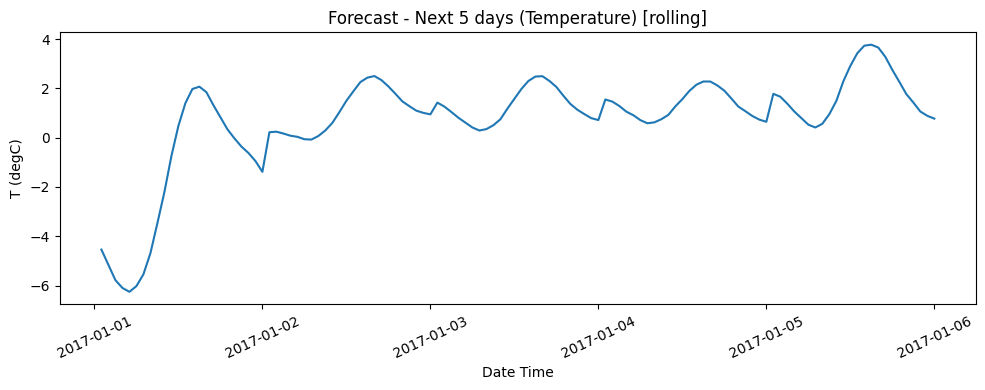

In [61]:
plt.figure(figsize=(10,4))
plt.plot(forecast_5d["Date Time"], forecast_5d["T_forecast_degC"])
plt.title("Forecast - Next 5 days (Temperature) [rolling]")
plt.xlabel("Date Time")
plt.ylabel("T (degC)")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

**Figure 109** - Five-Day Temperature Forecast Generated Using Rolling Predictions with the PatchTST Transformer Model (°C)

# 11. Limitations and Future Work

Although the results obtained in this study demonstrate that deep learning models can effectively capture temperature dynamics and produce accurate short-term forecasts, several limitations should be acknowledged.

First, the experiments were conducted using data from a single meteorological station. While this allows for a controlled evaluation of the forecasting models, it may limit the generalizability of the findings to other geographical locations or climatic conditions. Weather patterns can vary significantly across regions, and model performance may differ when applied to datasets with different seasonal structures or variability.

Second, the forecasting framework relies on approximations for future values of exogenous meteorological variables when generating extended forecasts. In the multi-day forecasting scenario, these variables were estimated using lagged observations, assuming a degree of temporal periodicity in the data. Although this approach provides a reasonable proxy, it introduces additional uncertainty that may affect long-horizon predictions.

Another limitation concerns the fixed prediction horizon used during training. Both the GRU and Transformer models were trained to produce forecasts for the next 24 hours. While rolling forecasting enables longer horizons to be generated, prediction errors can accumulate as forecasts extend further into the future, which may reduce reliability in longer-term predictions.

Additionally, although extensive hyperparameter optimization was performed using Optuna, the search space was still constrained by computational resources. More exhaustive exploration of architectural variations, learning rate schedules, and regularization strategies could potentially lead to further improvements in performance.

Future research could address these limitations in several ways. One possible direction is to evaluate the models across multiple weather stations or larger spatial datasets, allowing the analysis of spatial generalization and regional weather dynamics. Another promising extension would be the implementation of probabilistic forecasting techniques, such as quantile regression or Bayesian neural networks, which could provide uncertainty estimates alongside point forecasts.

Further work could also investigate more advanced time-series Transformer architectures that have recently been proposed in the literature, such as Informer, Autoformer, or FEDformer, which are specifically designed for long-horizon forecasting. These models may offer improved scalability and performance when predicting longer time horizons.

Finally, incorporating additional sources of information, such as numerical weather prediction outputs or satellite-based measurements, could further enhance forecasting accuracy by providing richer contextual information for the models.

While the present study demonstrates the effectiveness of deep learning approaches for temperature forecasting, addressing these limitations would provide valuable insights into the robustness, scalability, and practical applicability of such models in real-world meteorological forecasting systems.

# 11. Conclusion

This study investigated the application of deep learning architectures for multi-step temperature forecasting using meteorological time series data. Two different neural network approaches were explored: a recurrent model based on Gated Recurrent Units (GRU) and a Transformer-based architecture inspired by the PatchTST framework. Both models were trained to predict the next 24 hours of temperature based on historical observations and additional meteorological variables.

 The GRU model demonstrated strong predictive performance and proved highly effective at capturing short-term temporal dependencies in the data. On the test set, the model achieved a Mean Absolute Error (MAE) of approximately 1.63°C, a Root Mean Squared Error (RMSE) of about 2.15°C, and an R² score of 0.924, indicating that the model explains a large proportion of the variance in the observed temperature series. Residual analysis showed that prediction errors were approximately centered around zero and mostly concentrated near small magnitudes, indicating stable and unbiased forecasts. The GRU model also produced smooth and realistic forecast trajectories, successfully tracking short-term temperature fluctuations. One notable observation was that the GRU architecture required relatively little regularization, suggesting that its sequential inductive bias naturally helps control overfitting in this forecasting setting.

The Transformer-based PatchTST model introduced a different modeling paradigm by leveraging self-attention mechanisms and patch-based representations of the time series. Through extensive hyperparameter optimization using Optuna, the Transformer model achieved strong predictive performance and demonstrated a high ability to capture global temporal patterns. 

On the scaled test set, the best configuration achieved a MAE of 0.197, RMSE of 0.260, and an R² score of 0.917, indicating that the model successfully captures a large proportion of the variance in the target series. After converting predictions back to the original temperature scale, the model achieved a test MAE of approximately 1.70°C and an R² score above 0.91, confirming strong forecasting accuracy in real-world units.

A detailed hyperparameter analysis revealed several insights about the behavior of the Transformer architecture. In contrast to the GRU model, the Transformer benefited from moderate regularization, particularly through the use of dropout and Gaussian noise. Additionally, relatively simple architectures with a small number of attention heads and encoder blocks often performed better than deeper or more complex configurations, suggesting that excessive model capacity may not be necessary for this type of meteorological forecasting task.

When compared against a persistence baseline, the Transformer model demonstrated clear improvements across all prediction horizons. Error growth over time remained controlled, indicating that the model successfully learns meaningful temporal dynamics rather than simply extrapolating recent observations.

Overall, both architectures proved capable of modeling temperature dynamics effectively, but they exhibit different strengths. In this study, the GRU model achieved slightly better overall predictive performance, suggesting that recurrent architectures remain highly competitive for meteorological time series forecasting tasks characterized by strong local temporal dependencies and periodic patterns. The Transformer model, on the other hand, provides greater modeling flexibility and the ability to capture broader temporal relationships through attention mechanisms.

These findings highlight that modern Transformer-based approaches can be successfully applied to time series forecasting problems traditionally dominated by recurrent models. However, the results also suggest that architectural complexity should be carefully balanced with the characteristics of the dataset. For moderately sized meteorological datasets with strong periodic patterns, relatively compact models—such as GRU architectures—may already provide highly competitive or even superior forecasting performance.